# Capstone Project: Student Depression Prediction

---

## 1. Overview
### Question: What Are the Top Three Factors Contributing to Depression in Students?

### 1.1 Business Context
It is important to be able to identify students who may require intervention for their emotional wellbeing. If the question is left unanswered, students who are emotionally unwell may suffer in silence without anyone ever noticing it. With a predictive model capable of identifying potentially emotionally unwell students, emotional and mental wellness institutions can gain insight on factors contributing to depress among students, and the predictive model can flag potentially depressed students to introduce early interventions.

The notebook aims to find a supervised classification machine learning model that can predict students' depress status based on data such as demographics, academic indicators, lifestyle, and other factors, to predict whether a student is depressed, and to identify the top three drivers impacting a student's emotional wellbeing, which may be beneficial to universtiy administration and mental health policy makers.

### 1.2 Techniques for Analysis
  1. Data Collection and Sourcing
  2. Exploratory Data Analysis
  3. Data Cleaning and Preprocessing
  4. Feature Engineering
  5. Data Splitting
  6. Model Selection - KNN, Logistic Regression, Random Forest, SVM, and XGBoost. Baseline: Simple Logistic Reression
  7. Model Training
  8. Hyperparameter Tuning - Grid Search CV
  9. Model Evaluation - Recall score
  10. Model Interpreation and Explainability - SHAP values
  11. Model Validation and Testing - Evaluation with Test Set, performance by subgroup, robustness to missing data

### 1.3 Success Criteria
A predictive classification model of > 0.90 recall score predicting whether a student is depressed. It should perform better than the baseline model.

---

## 2. Data Collection and Sourcing

### 2.1 Data Sourcing

The data is sourced from the Kaggle [website](https://www.kaggle.com/datasets/adilshamim8/student-depression-dataset), titled "Student depress Dataset". The dataset has 18 columns and total of 27901 rows, which is adequate for data analysis. Based on the Kaggle website, the data was compiled through multiple datasets from OpenML.org, and senstitive information was removed or encoded to achieve anonymity. The dataset is adequate for reasearch purposes.

Feature Description from the Data Source:

- id — A unique identifier assigned to each student record in the dataset..
- Gender — The gender of the student, Male or Female.
- Age — The age of the studnet in years.
- City — The city or region where the student resides, providing geographical context for the analysis.
- Profession — The field of work or study of the student, which may offer insights into occupational or academic stress factors.
- Academic Pressure — A measure indicating the level of pressure the student faces in academic settings. This could include stress from exams, assignments, and overall academic expectations. 0-5.
- Work Pressure — A measure of the pressure related to work or job responsibilities, relevant for students who are employed alongside their studies. 0-5.
- CGPA — The cumulative grade point average of the student, reflecting overall academic performance. 0-10.
- Study Satisfaction — An indicator of how satisfied the student is with their studies, which can correlate with mental well-being. 0-5.
- Job Satisfaction — A measure of the student’s satisfaction with their job or work environment, if applicable.
- Sleep Duration — The average number of hours the student sleeps per day, which is an important factor in mental health. 0-4. Less than 5 hours, 7-8 hours, and Others.
- Dietary Habits — An assessment of the student’s eating patterns and nutritional habits, potentially impacting overall health and mood. Healty, Unhealthy, Moderate, Others.
- Degree — The academic degree or program that the student is pursuing. Various.
- Have you ever had suicidal thoughts ?: A binary indicator (Yes/No) that reflects whether the student has ever experienced suicidal ideation. 
- Work/Study Hours — The average number of hours per day the student dedicates to work or study, which can influence stress levels. 0-12.
- Financial Stress — A measure of the stress experienced due to financial concerns, which may affect mental health. 1-5.
- Family History of Mental Illness — Indicates whether there is a family history of mental illness (Yes/No), which can be a significant factor in mental health predispositions.
- Depression — The target variable that indicates whether the student is experiencing depress (Yes/No = 0/1). This is the primary focus of the analysis. 

The dataset is anonymous and does not violate privacy. which is adequate for research and educational purposes. 

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import xgboost as xgb
import shap

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

import time
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, RocCurveDisplay
from sklearn.metrics import classification_report, accuracy_score
from sklearn.datasets import make_classification

from sklearn.inspection import permutation_importance
from sklearn import set_config
# Set color scheme
colors = sns.color_palette('Pastel1')
sns.set_palette('Pastel1')
sns.set_style('whitegrid')

# Suppress warnings
import os
os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"
pd.options.mode.chained_assignment = None # Disable the warning
warnings.simplefilter(action='ignore', category=FutureWarning)
set_config("display")
plt.rcParams.update({'font.size': 12})
RANDOM_STATE = 42

### 2.2 Read in the Data

In [278]:
# Read in the file
depress = pd.read_csv('data/student_depression_dataset.csv')

---
## 3. Exploratory Data Analysis - Initial Inspection

### 3.1 Initial Inspection

In [279]:
depress.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [280]:
depress.isnull().sum().sort_values()

id                                       0
Financial Stress                         0
Work/Study Hours                         0
Have you ever had suicidal thoughts ?    0
Degree                                   0
Dietary Habits                           0
Sleep Duration                           0
Job Satisfaction                         0
Study Satisfaction                       0
CGPA                                     0
Work Pressure                            0
Academic Pressure                        0
Profession                               0
City                                     0
Age                                      0
Gender                                   0
Family History of Mental Illness         0
Depression                               0
dtype: int64

There is no null values.

In [281]:
depress.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


---
## 4. Exploratory Data Analysis and Data Cleaning

### 4.1 Feature Examination and Data Cleaning

Drop `id` column because it is not useful.

In [282]:
# Drop 'id' column
depress.drop(columns=['id'], inplace=True)

Define target, categorical and numerical features for EDA.

In [283]:
# Define target column
target = 'Depression'
depress[target] = depress[target].replace(1,"Yes")
depress[target] = depress[target].replace(0,"No")

# Identify numerical and categorical column names
cat_features = depress.select_dtypes(include=["object", "category"]).columns.tolist()
num_features = depress.select_dtypes(include=[np.number]).columns.tolist()
cat_features.remove('Depression') # Remove target variable from categorical features list

Now examine value distribution for each categorical feature.

In [284]:
# Print value distribution for categorical features
for col in cat_features:
    print(f"Value Distribution for {col}:")
    print(depress[col].value_counts(normalize=True))
    print("\n")

Value Distribution for Gender:
Gender
Male      0.55722
Female    0.44278
Name: proportion, dtype: float64


Value Distribution for City:
City
Kalyan                  0.056270
Srinagar                0.049174
Hyderabad               0.048027
Vasai-Virar             0.046235
Lucknow                 0.041396
Thane                   0.040823
Ludhiana                0.039819
Agra                    0.039210
Surat                   0.038637
Kolkata                 0.038207
Jaipur                  0.037131
Patna                   0.036092
Visakhapatnam           0.034730
Pune                    0.034694
Ahmedabad               0.034085
Bhopal                  0.033476
Chennai                 0.031719
Meerut                  0.029569
Rajkot                  0.029246
Delhi                   0.027526
Bangalore               0.027490
Ghaziabad               0.026702
Mumbai                  0.025053
Vadodara                0.024874
Varanasi                0.024551
Nagpur                  0.023332

Based on the output above, the following decisions are made:
- Drop the columns `City` and `Degree` because they have too many values, which present challenges for machine learning. Addtionally, `City` has values like `3.0` and `City`,  which are likely errors and cannot be imputed, and `Class 12` accounts for 21.8% of entries in `Degree`.
- For `Profession`, 
    - Drop  the rows with value not equal to `Student` because they represent less than 1 percent of the data.
    - Remove the column entirely because all the values are `Student`. 
- For `Sleep Duration`:
    - Drop the rows with value equal to `Others` because they represent only 0.06 percent of the data.
    - Convert `Less than 5 hours` to `5`.
    - Convert `7-8 hours` to `8`.
    - Convert `5-6 hours` to `6`.
    - Convert `More than 8 hours` to `10`.
    - Convert the data type of the column to numerical.
- For `Dietary Habits`, drop the rows with value equal to `Others` because they represent only 0.04 percent of the data.
- For `Financial Stress`, drop the rows with value equal to`?` because they represent only 0.01 percent of the data, and convert the data type of `Financial Stress` to numerical.
- Rename column `Have you ever had suicidal thoughts ?` to `Has Had Suicidal Thoughts`.
- Re-define `num_features` and `cat_features`.

In [285]:
# Drop City and Degree columns due to high cardinality and low variance
depress.drop(columns=['City', 'Degree'], inplace=True)

# Keep only the rows where "Profession" is "Student" and remove the column since all the values are "Student"
depress = depress[depress['Profession'] == 'Student']
depress.drop(columns=['Profession'], inplace=True)

# Keep only the rows where "Sleep Duration" is not "Others"
depress = depress[depress['Sleep Duration'] != 'Others']

# Convert object values to numeric values in "Sleep Duration" column
depress['Sleep Duration'] = depress['Sleep Duration'].str.replace("Less than 5 hours", '3.5')
depress['Sleep Duration'] = depress['Sleep Duration'].str.replace("7-8 hours", '7.5')
depress['Sleep Duration'] = depress['Sleep Duration'].str.replace("5-6 hours", '5.5')
depress['Sleep Duration'] = depress['Sleep Duration'].str.replace("More than 8 hours", '9.5')
# Strip extra quotes
depress['Sleep Duration'] = depress['Sleep Duration'].astype(str).str.strip("'").astype(float)

# Keep only the rows where "Dietary Habits" is not "Others"
depress = depress[depress['Dietary Habits'] != 'Others']

# Keep only the rows where "Financial Stress" is not "?" and convert the column to numeric values
depress = depress[depress['Financial Stress'] != '?']
depress['Financial Stress'] = pd.to_numeric(depress['Financial Stress'], errors='coerce')

# Rename column `Have you ever had suicidal thoughts ?` to `Has Had Suicidal Thoughts` for better readability
depress.rename(columns={'Have you ever had suicidal thoughts ?': 'Has Had Suicidal Thoughts'}, inplace=True)

# Re-define numerical and categorical column names
cat_features = depress.select_dtypes(include=["object", "category"]).columns.tolist()
num_features = depress.select_dtypes(include=[np.number]).columns.tolist()
cat_features.remove('Depression') # Remove target variable from categorical features list

depress.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27837 entries, 0 to 27900
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Gender                            27837 non-null  object 
 1   Age                               27837 non-null  float64
 2   Academic Pressure                 27837 non-null  float64
 3   Work Pressure                     27837 non-null  float64
 4   CGPA                              27837 non-null  float64
 5   Study Satisfaction                27837 non-null  float64
 6   Job Satisfaction                  27837 non-null  float64
 7   Sleep Duration                    27837 non-null  float64
 8   Dietary Habits                    27837 non-null  object 
 9   Has Had Suicidal Thoughts         27837 non-null  object 
 10  Work/Study Hours                  27837 non-null  float64
 11  Financial Stress                  27837 non-null  float64
 12  Family Hi

### 4.2 Remove Outliers


Apply IQR to numerical features to remove outliers.

In [286]:
# Remove outliers for numerical columns using IQR method
previous_data_size = depress.shape[0]
for col in num_features: 
    Q1 = depress[col].quantile(0.25)
    Q3 = depress[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    depress = depress[(depress[col] >= lower_bound) & (depress[col] <= upper_bound)]

# Check resulting data after outliers and unreasonable data rows are removed
depress.info()
print(f"\nThis removes {(previous_data_size - depress.shape[0])/previous_data_size*100:.2f}% of the data.")

<class 'pandas.core.frame.DataFrame'>
Index: 27814 entries, 0 to 27900
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Gender                            27814 non-null  object 
 1   Age                               27814 non-null  float64
 2   Academic Pressure                 27814 non-null  float64
 3   Work Pressure                     27814 non-null  float64
 4   CGPA                              27814 non-null  float64
 5   Study Satisfaction                27814 non-null  float64
 6   Job Satisfaction                  27814 non-null  float64
 7   Sleep Duration                    27814 non-null  float64
 8   Dietary Habits                    27814 non-null  object 
 9   Has Had Suicidal Thoughts         27814 non-null  object 
 10  Work/Study Hours                  27814 non-null  float64
 11  Financial Stress                  27814 non-null  float64
 12  Family Hi

The removal of 0.08% data is acceptable (< 5%).

### 4.3 Categorical Feature Analysis

Check whether target column distribution is balanced or umbalanced.

In [287]:
# Check target variable distribution
depress[target].value_counts(normalize=True)

Depression
Yes    0.585425
No     0.414575
Name: proportion, dtype: float64

The outcome classes are balanced.

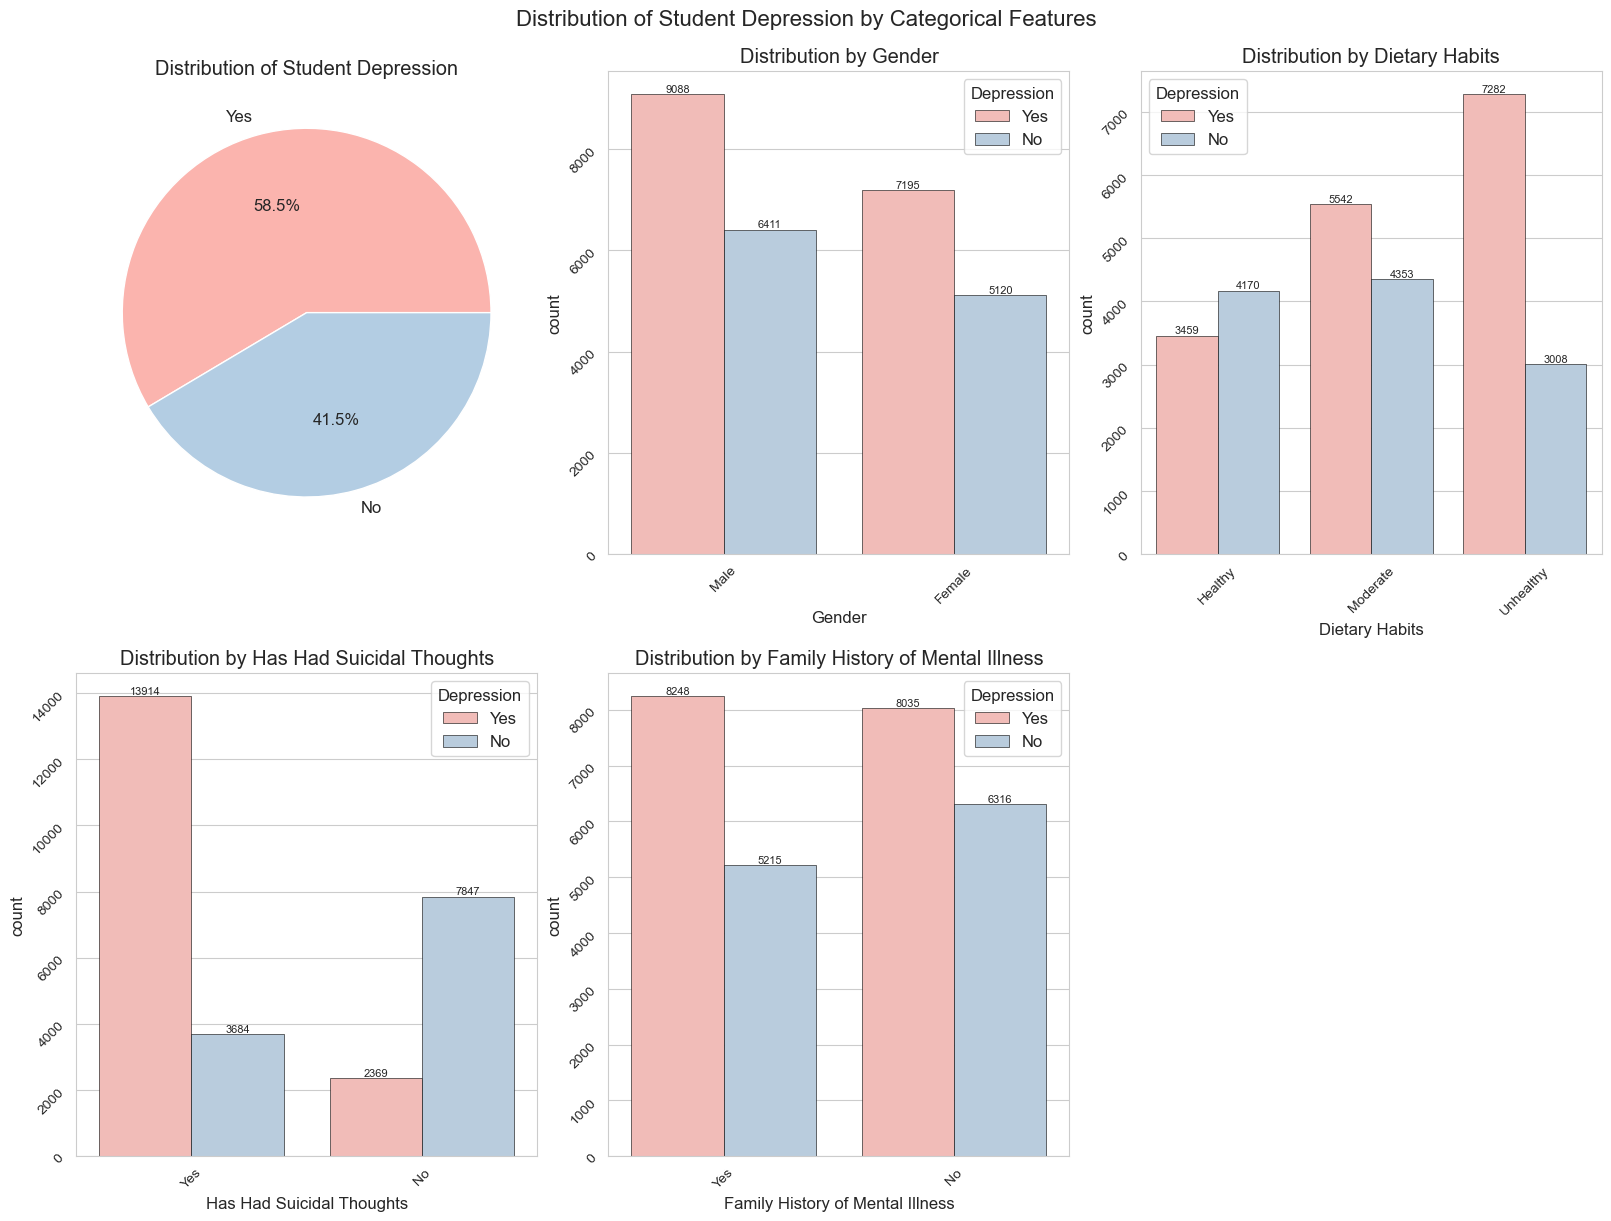

In [288]:
# Convert order of the target column for readability 
depress[target] = pd.Categorical(depress[target], ["Yes", "No"])

# Set up subplots
fig,_axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 12), layout='constrained')
axes=_axes.flatten()

# Delete unused subplot and adjust spacing
fig.delaxes(axes[-1]) 

# Plot distribution of target variable 
axes[0].pie(depress['Depression'].value_counts(), labels=depress['Depression'].value_counts().index, autopct='%1.1f%%', colors=colors)
axes[0].set_title('Distribution of Student Depression')

# Plot distributions of categorical features by target variable
i=1
for col in cat_features:
    order = depress[col].value_counts().index.to_list()
    if (col =='Gender'):
        order = ['Male','Female']
    elif (col == 'Dietary Habits'):
        order = ["Healthy", "Moderate", "Unhealthy"]
    else: 
        order = ["Yes", "No"]
    depress[col] = pd.Categorical(depress[col], order)
    ax = sns.countplot(data=depress, x=col, edgecolor='black', linewidth=0.4, ax=axes[i], hue='Depression')
    for container in ax.containers:
        ax.bar_label(container, label_type='edge',fontsize=8)
    ax.tick_params(labelrotation=45, labelsize=10)
    ax.set_title(f'Distribution by {col}')
    i=i+1
    
plt.suptitle('Distribution of Student Depression by Categorical Features', fontsize=16, verticalalignment='center')
plt.show()

The plot suggests:
- The dataset is a balanced dataset where 58.5% of the students have depression, and 41.5% of the students do not have depression.
- Male and females students do not have a signficant difference in mental wellbeing.
- Those with unhealthy dietary habits tend to be more likely to be depressed.
- Those who have had suicidal thoughts are more likely to be depressed at the present moment.
- Those with a family history of mental illness seem slightly more likely to be depressed. 

### 4.4 Univariate Analysis for Numerical Features

In [289]:
depress.describe()

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Work/Study Hours,Financial Stress
count,27814.000000,27814.000000,27814.0,27814.000000,27814.000000,27814.0,27814.000000,27814.000000,27814.000000
mean,25.808981,3.141691,0.0,7.658568,2.943949,0.0,6.298159,7.159704,3.139426
std,4.878918,1.381166,0.0,1.464635,1.360406,0.0,2.253493,3.706372,1.437304
min,18.000000,0.000000,0.0,5.030000,0.000000,0.0,3.500000,0.000000,1.000000
25%,21.000000,2.000000,0.0,6.290000,2.000000,0.0,3.500000,4.000000,2.000000
50%,25.000000,3.000000,0.0,7.770000,3.000000,0.0,5.500000,8.000000,3.000000
75%,30.000000,4.000000,0.0,8.920000,4.000000,0.0,7.500000,10.000000,4.000000
max,43.000000,5.000000,0.0,10.000000,5.000000,0.0,9.500000,12.000000,5.000000


Remove `Work Pressure` and `Job Satisfaction` columns since all the values are 0.

In [290]:
# Remove "Work Pressure" and "Job Satisfaction" columns 
depress.drop(columns=['Work Pressure', 'Job Satisfaction'], inplace=True)

# Convert the column "Work/Study Hours" to "Study Hours" for better readability
depress.rename(columns={'Work/Study Hours': 'Study Hours'}, inplace=True)

# Re-define numerical column names after renaming
num_features = depress.select_dtypes(include=[np.number]).columns.tolist()

Plot distributions of numerical features with histograms.

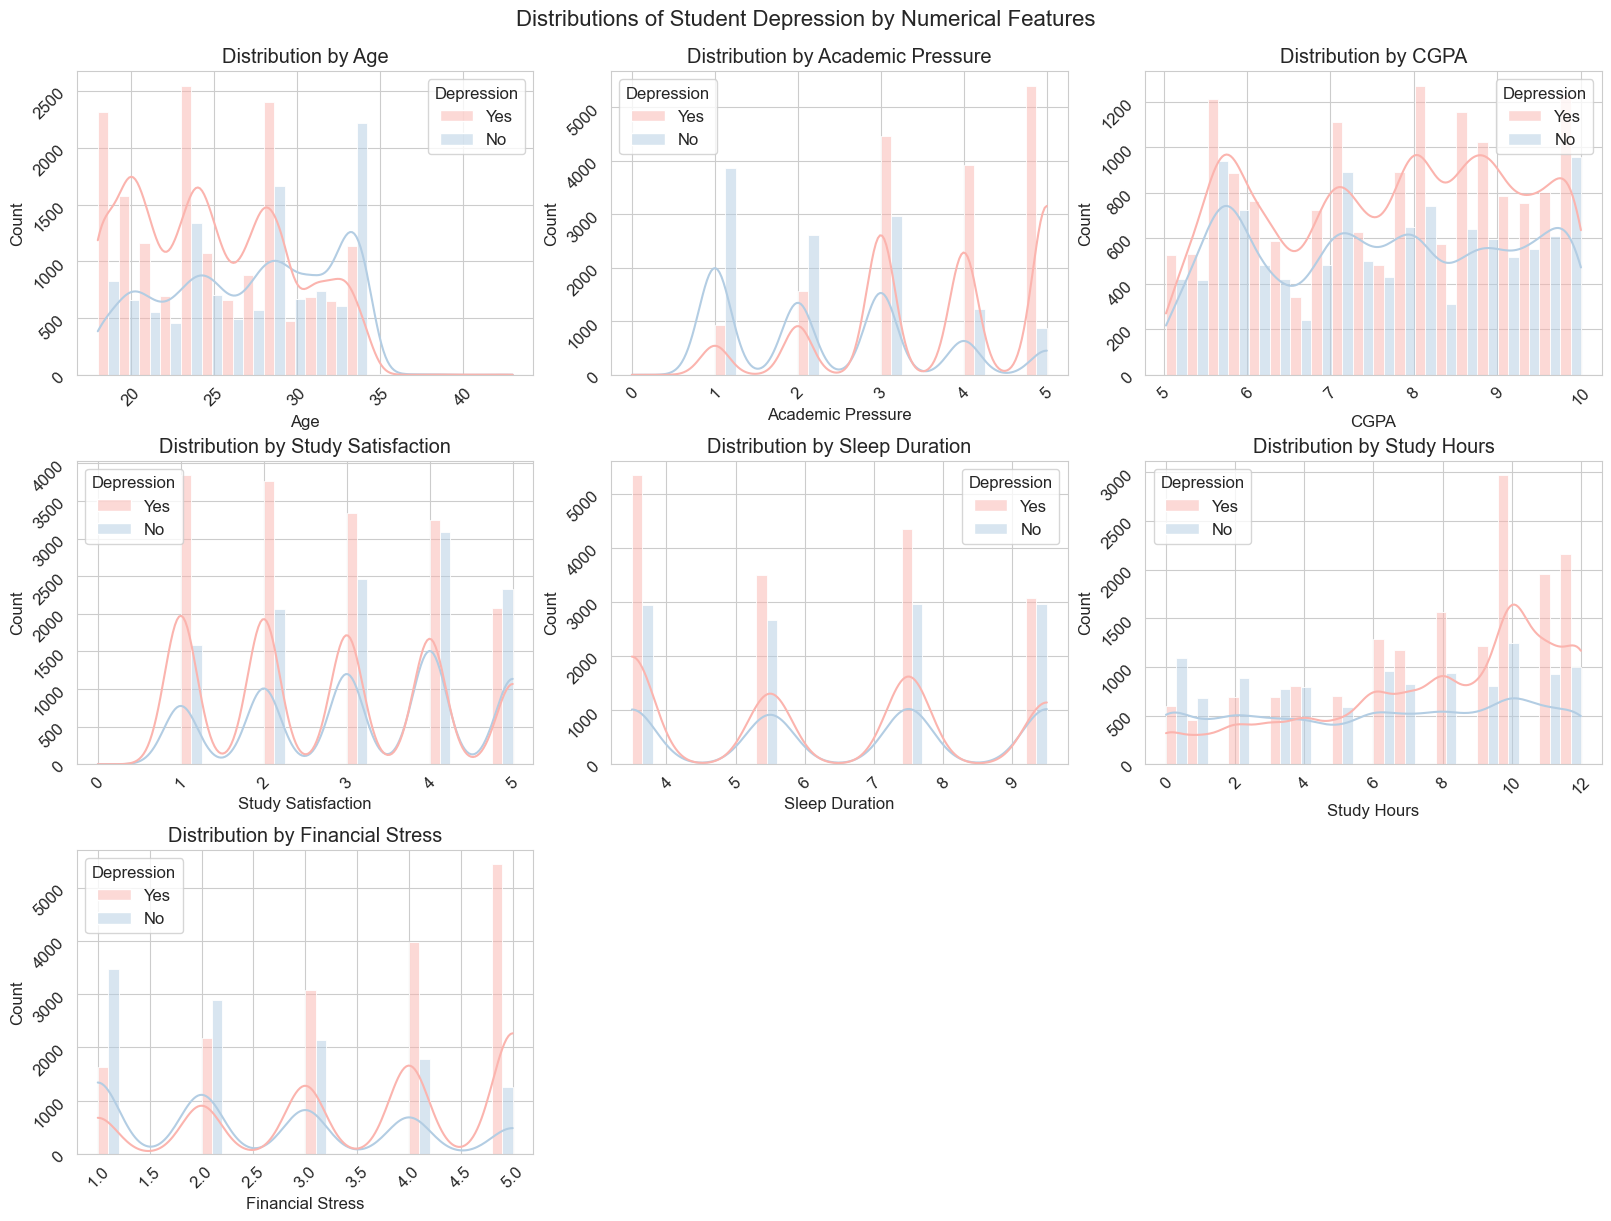

In [291]:
# Set up subplots
fig,_axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12), layout='constrained')
axes=_axes.flatten()

# Delete unused subplot and adjust spacing
fig.delaxes(axes[-1]) 
fig.delaxes(axes[-2]) 

# Plot the numercial distrubtions with violin plots
i=0
for col in num_features:
    ax = sns.histplot(data =depress, x =col, bins=20, ax=axes[i], multiple='dodge',kde=True, hue = target)
    ax.tick_params(labelrotation=45, labelsize=12)
    ax.set_title(f'Distribution by {col}')
    i=i+1

plt.suptitle('Distributions of Student Depression by Numerical Features', fontsize=16, verticalalignment='center')
plt.show()

Plot numerical data distributions with violin plots to compare distributions of depressed and non-depressed students side by side.

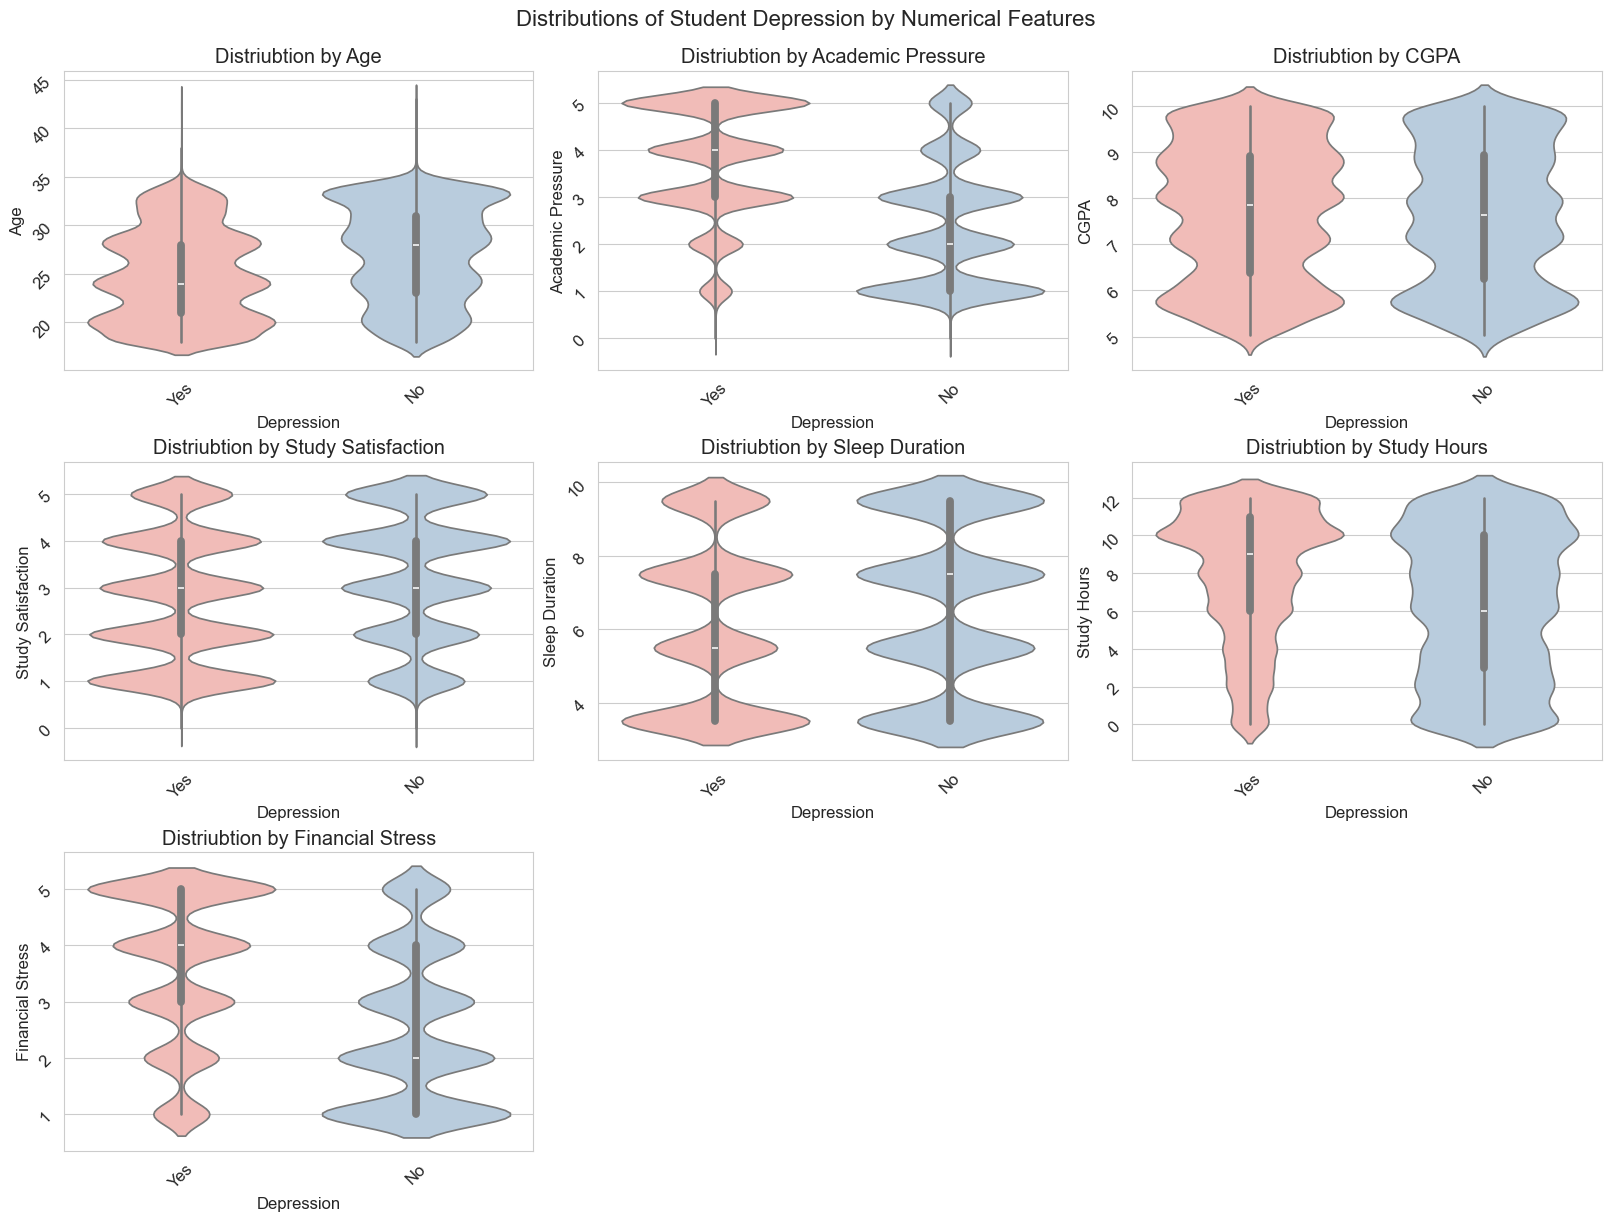

In [292]:
# Set up subplots
fig,_axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12), layout='constrained')
axes=_axes.flatten()

# Delete unused subplot and adjust spacing
fig.delaxes(axes[-1]) 
fig.delaxes(axes[-2]) 

# Plot the numercial distrubtions with violin plots
i=0
for col in num_features:
    ax = sns.violinplot(data =depress, y =col, ax=axes[i],  x = target , hue=target)
    ax.tick_params(labelrotation=45, labelsize=12)
    ax.set_title(f'Distriubtion by {col}')
    i=i+1


plt.suptitle('Distributions of Student Depression by Numerical Features', fontsize=16, verticalalignment='center')
plt.show()

The univariate analysis suggests:
- Those who are younger may be slightly more prone to depression. 
- Those with higher academic pressure may be more prone to depression.
- Those who sleep less may be more prone to depression.
- Those who study less are less likely to be depressed, but those who study more may not be necessarily depressed.
- Those with higher financial stress may be more prone to depression.
- Study satisfaction and academic performance do not seem to be strong predictors of student depression.

### 4.5 Bivariate Analysis for Numerical Features

Check correlations between numerical features.

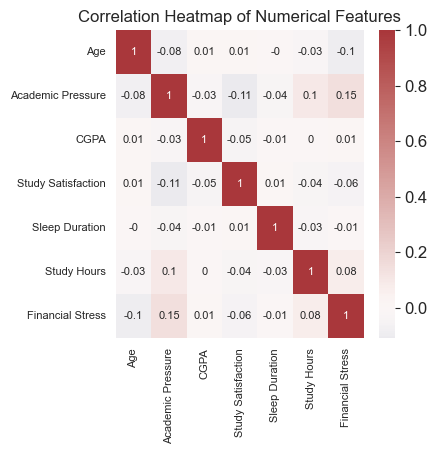

In [293]:
# Correlation heatmap of numerical features
fig, ax = plt.subplots(figsize=(4,4))      
ax = sns.heatmap(round(depress[num_features].corr(), 2), annot=True, center=0,cmap="vlag", annot_kws={'size': 8})
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
plt.title('Correlation Heatmap of Numerical Features', fontsize=12)
plt.show()

<Figure size 1600x1600 with 0 Axes>

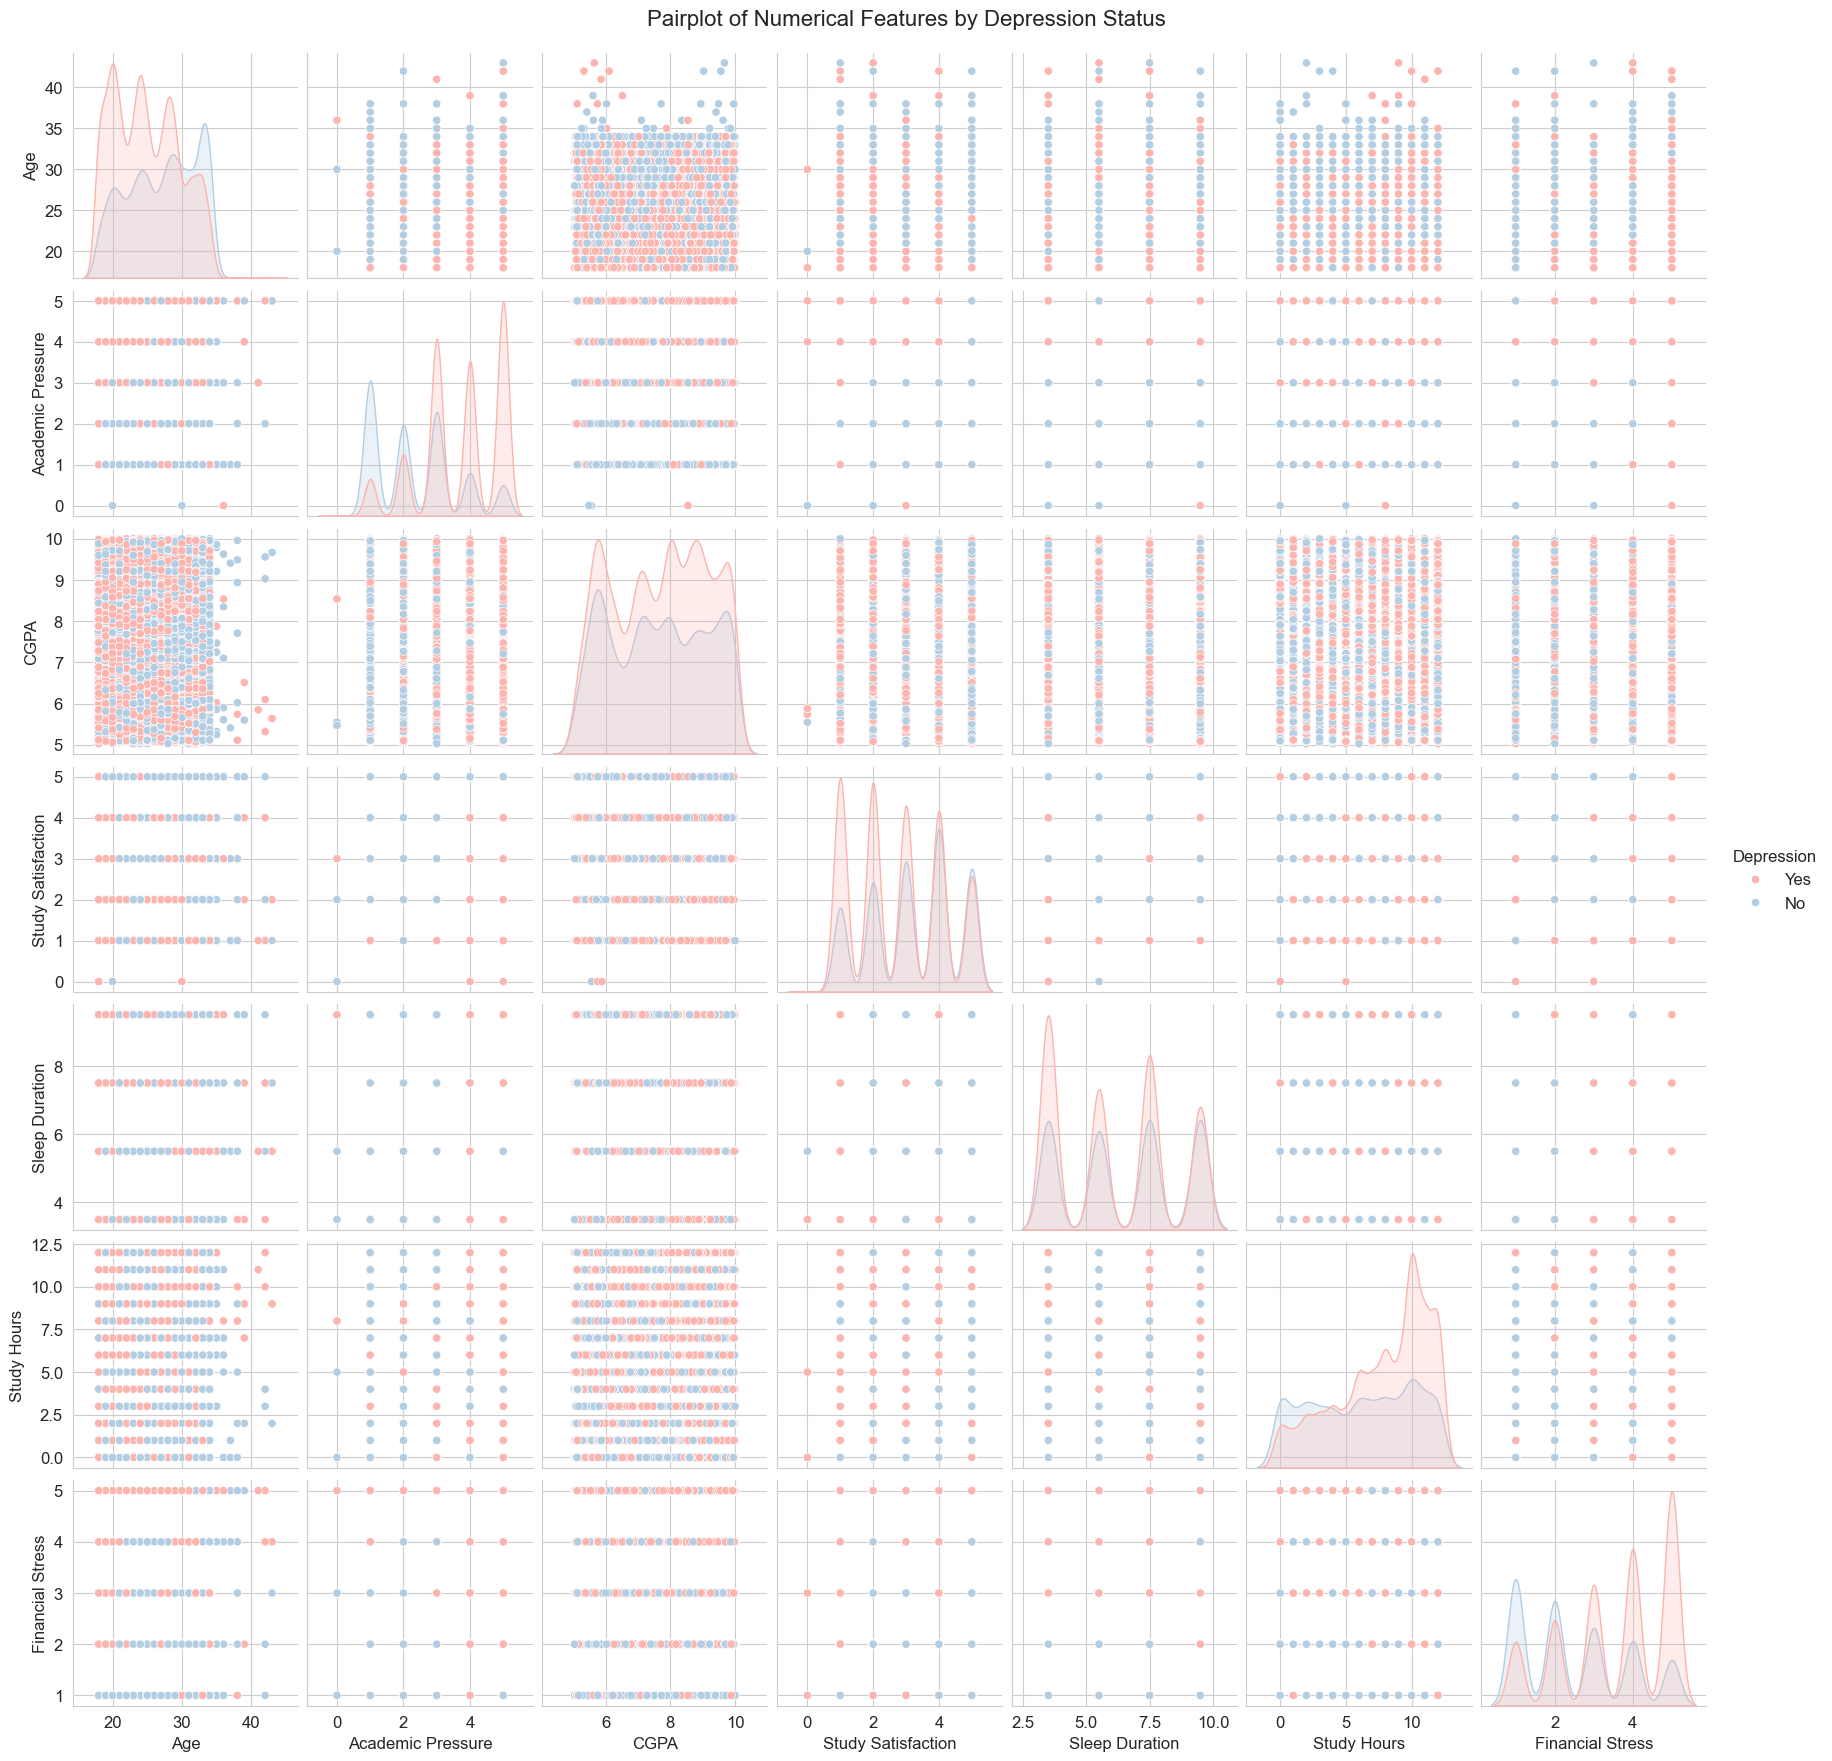

In [294]:
# Pairplot of numerical features colored by target variable
plt.figure(figsize=(16, 16))
g = sns.pairplot(depress, diag_kind="kde", hue=target)
g.figure.suptitle("Pairplot of Numerical Features by Depression Status", fontsize=16, y=1.01)
plt.show()
plt.show()

The bivariate analysis suggets that numerical features do not have significant correlations with one another.

---
## 5. Feature Engineering

Encode categorical features and scale numerical features.

In [24]:
# Define features (X) and target (y)
X = depress.drop(columns=target)
y = depress[target]

# Encode the target variable
le = LabelEncoder()
y = le.fit_transform(y)

In [31]:
# Define data preprocessing pipelines for numerical and categorical features
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ],
    remainder="drop"
)

---
## 6. Data Splitting

In [26]:
# Split the data into training, validation, and test sets (70% train, 15% validation, 15% test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE)

# Print the sizes of the resulting sets
print(f"Total samples: {len(X)}")
print(f"Train set samples: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Validation set samples: {len(X_val)} ({len(X_val)/len(X)*100:.0f}%)")
print(f"Test set samples: {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")

Total samples: 27814
Train set samples: 19469 (70%)
Validation set samples: 4172 (15%)
Test set samples: 4173 (15%)


---
## 7. Model Selection

### 7.1 Baseline Model
A simple Logistic Regression model is chosen as the baseline model. Examine the metrics of the baseline model. 

In [295]:
# A simple logistic regression baseline model

baseline_pipe= Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(random_state=RANDOM_STATE))
])

baseline_pipe.fit(X_train, y_train)
train_preds = baseline_pipe.predict(X_train)
val_preds = baseline_pipe.predict(X_val)

# Calculate baseline model scores - precision, recall, and F1 scores
baseline_train_precision = precision_score(y_train, train_preds)
baseline_val_precision = precision_score(y_val, val_preds)
baseline_train_recall = recall_score(y_train, train_preds)
baseline_val_recall = recall_score(y_val, val_preds)
baseline_train_f1 = f1_score(y_train, train_preds)
baseline_val_f1 = f1_score(y_val, val_preds)

#Print baseline model score
print("Our classifier should perform better than the baseline model performances below:\n")
print(f"Baseline Train Precision Score: {baseline_train_precision:.3}")
print(f"Baseline Validation Precision Score: {baseline_val_precision:.3}\n")
print(f"Baseline Train Recall Score: {baseline_train_recall:.3}")
print(f"Baseline Validation Recall Score: {baseline_val_recall:.3}\n")
print(f"Baseline Train F1 Score: {baseline_train_f1:.3}")
print(f"Baseline Validation F1 Score: {baseline_val_f1  :.3}")

Our classifier should perform better than the baseline model performances below:

Baseline Train Precision Score: 0.858
Baseline Validation Precision Score: 0.854

Baseline Train Recall Score: 0.888
Baseline Validation Recall Score: 0.888

Baseline Train F1 Score: 0.872
Baseline Validation F1 Score: 0.871


RECALL SCORE is chosen as the metric because it is crucial not to miss any student who are potentially depressed because one who's left untreated may deterioate and harm oneself, harm others, or commit suicide. The cost of misdiagnosis is high.

### 7.2 Define Models and Initial Hyperparameters

In [296]:
# Define models and hyperparameters
models_1= {
    'Logistic Regression': (LogisticRegression(random_state=RANDOM_STATE, max_iter=1000), {'Logistic Regression__C': [0.01, 0.1, 1, 10]}),
    'KNN': (KNeighborsClassifier(), {'KNN__n_neighbors': [3, 5, 7, 9]}),
    'Random Forest': (RandomForestClassifier(random_state=RANDOM_STATE), {'Random Forest__max_depth': [4, 8, 12, 16], 'Random Forest__n_estimators': [50, 100, 200]}), 
    'SVM': (SVC(random_state=RANDOM_STATE), {'SVM__C': [0.1, 1, 10], 'SVM__kernel': ['linear', 'rbf']})
}

---
## 8. Inital Model Training

In [ ]:
results_grid_1 = []
best_models_1 = {}

for name, (model, params) in models_1.items():
    # Create a pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        (name, model)
    ])
    
    # Perform grid search
    grid = GridSearchCV(pipeline, param_grid=params, cv=5, n_jobs=-1, scoring='recall')
    
    # Fit the model and time it
    start_time = time.time()
    grid = grid.fit(X_train, y_train)
    fit_time = (time.time() - start_time) / len(grid.cv_results_['mean_fit_time'])
    
    # Get the best estimator
    best_models_1[name] = grid.best_estimator_
    
    best_train_precision_score = precision_score(y_train, grid.best_estimator_.predict(X_train))
    best_train_recall_score = recall_score(y_train, grid.best_estimator_.predict(X_train))
    best_train_f1_score = f1_score(y_train, grid.best_estimator_.predict(X_train))
   
    best_val_precision_score = precision_score(y_val, grid.best_estimator_.predict(X_val))
    best_val_recall_score = recall_score(y_val, grid.best_estimator_.predict(X_val))
    best_val_f1_score = f1_score(y_val, grid.best_estimator_.predict(X_val))
    best_params = grid.best_params_

    # Append the results and best model
    results_grid_1.append([name, fit_time,
                           best_train_precision_score, best_train_recall_score, best_train_f1_score,
                           best_val_precision_score, best_val_recall_score, best_val_f1_score,
                           best_params])

In [ ]:
# Set max column width to 100 characters
pd.set_option('display.max_colwidth', 1000)

# Create the results DataFrame
results_grid_1_df = pd.DataFrame(results_grid_1, columns=['Model', 'Train Time (s)',
                                                          'Train Precision Score', 'Train Recall Score', 'Train F1 Score',
                                                          'Validation Precision Score', 'Validation Recall Score', 'Validation F1 Score',
                                                          'Best Parameters'])
results_grid_1_df = results_grid_1_df.sort_values(by='Validation Recall Score', ascending=False).reset_index(drop=True)
results_grid_1_df

,Model,Train Time (s),Train Precision Score,Train Recall Score,Train F1 Score,Validation Precision Score,Validation Recall Score,Validation F1 Score,Best Parameters
0,Logistic Regression,1.119866,0.855970,0.889818,0.872566,0.852930,0.891492,0.871785,{'Logistic Regression__C': 0.01}
1,SVM,6.891737,0.857429,0.896263,0.876416,0.848865,0.891081,0.869461,"{'SVM__C': 0.1, 'SVM__kernel': 'rbf'}"
2,Random Forest,1.130563,0.864104,0.898876,0.881148,0.847484,0.886149,0.866385,"{'Random Forest__max_depth': 8, 'Random Forest__n_estimators': 50}"
3,KNN,0.266807,0.859083,0.909067,0.883369,0.835144,0.884916,0.859310,{'KNN__n_neighbors': 9}


The best model with the intial sets of hyperparameters is Logistic Regression, with validation recall score of 0.8914. There does not seem to be immediate overfitting because the train scores and validation scores are very close.

Plot the results to visualize.

In [ ]:
# Set up subplots
fig,_axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5), layout='constrained')
axes=_axes.flatten()

# Plot training time across models
axes[0] = sns.barplot(x='Model', y='Train Time (s)', linewidth=0.4, data=results_grid_1_df, ax=axes[0], width=0.4)  
axes[0].set_title('Training Time by Model')

for container in axes[0].containers:
        axes[0].bar_label(container,  fmt='{:.3f}s', label_type='edge',fontsize=9)

# Plot training and validation scores
# Recall score
results_grid_1_melted = results_grid_1_df.melt(id_vars='Model', value_vars=['Train Recall Score', 'Validation Recall Score'], var_name='Dataset', value_name='Recall Score')
axes[1]=sns.barplot(x='Model', y='Recall Score', hue='Dataset', linewidth=0.4, data=results_grid_1_melted, ax=axes[1], width=0.6)
axes[1].set_title('Recall Scores by Model')
for container in axes[1].containers:
        axes[1].bar_label(container,  fmt='{:.3f}', label_type='edge',fontsize=9)
sns.move_legend(axes[1], "best", bbox_to_anchor=(1, 1), title="Dataset")

plt.suptitle('Training Time and Recall Scores by Initial Models (Recall)', fontsize=16, verticalalignment='center')
plt.show()

---
## 9. Hyperparameter Tuning

Based on the output from the initial model, the hyperparameters are modified to see if the recall scores can be improved.

First, plot the elbow graph for KNN to visualize the best potential k-range.

In [ ]:
# Plot elbow graph for the KNN model to visualize the optimal number of neighbors
from sklearn.model_selection import cross_val_score
# Define a new k-range
k_range = range(3, 100, 5)
cv_scores = []
cv_std = []

for k in k_range:
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('knn', KNeighborsClassifier(n_neighbors=k))  
    ])
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='recall')  
    cv_scores.append(scores.mean())

cv_scores = np.array(cv_scores)

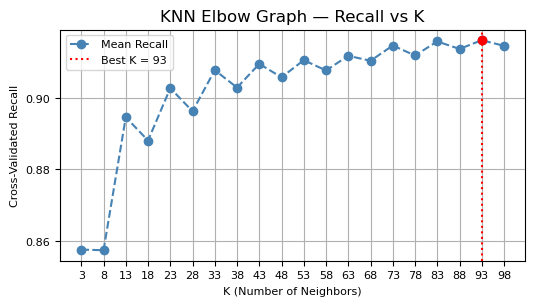

Best K: 93 | Recall: 0.9161


In [ ]:
# Plot the elbow graph
best_k_idx = np.argmax(cv_scores)
best_k = k_range[best_k_idx]

plt.figure(figsize=(6, 3))
plt.plot(k_range, cv_scores, marker='o', linestyle='--', color='steelblue', label='Mean Recall')
plt.axvline(x=best_k, color='red', linestyle=':', label=f'Best K = {best_k}')
plt.scatter([best_k], [cv_scores[best_k_idx]], color='red', zorder=5)

plt.title('KNN Elbow Graph — Recall vs K', fontsize=12)
plt.xlabel('K (Number of Neighbors)', fontsize=8)
plt.ylabel('Cross-Validated Recall', fontsize=8)
plt.xticks(k_range, fontsize=8)
plt.yticks(fontsize=8)
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

print(f"Best K: {best_k} | Recall: {cv_scores[best_k_idx]:.4f}")

The best k is near the upper end of the range. Tune the hyperparameters acoordingly. Other hyperparameters are also added to see if model performance can be imrpoved. 

### 9.1 Hyperparameter Tuning - First Round

Tune hyperparameters of the previous modesl and add XGBoost.

In [ ]:
# New hyperparameters
models_2 = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                            {'Logistic Regression__C': [0.001, 0.01, 0.1, 1, 10], # wider range 
                             'Logistic Regression__penalty': ['l1', 'l2'],
                             'Logistic Regression__solver': ['liblinear', 'saga']}), # add more solvers
    'KNN': (KNeighborsClassifier(),
            {'KNN__n_neighbors': range (80, 120, 2), # based on the elbow graph, focus on a narrower range
            'KNN__weights': ['uniform', 'distance'], # add weights hyperparameter
            'KNN__metric': ['euclidean', 'manhattan']}), # add metric hyperparameter
    'Random Forest': (RandomForestClassifier(random_state=RANDOM_STATE),
                        {'Random Forest__max_depth': [8, 12, 16, None], # add full depth option
                         'Random Forest__n_estimators': [100, 200, 300],   
                         'Random Forest__min_samples_split': [2, 5, 10],
                         'Random Forest__max_features': ['sqrt', 'log2'], # add max features hyperparameter
                         'Random Forest__min_samples_leaf': [1, 2, 4] }), 
    'SVM': (SVC(random_state=RANDOM_STATE),
                        {'SVM__C': [0.1, 1, 10],          
                        'SVM__kernel': ['linear', 'rbf'], 
                        'SVM__gamma': ['scale', 'auto'] }), # add gamma hyperparameter
    'XGBoost': (XGBClassifier(  random_state=RANDOM_STATE, # add XGBoost model with hyperparameters
                                eval_metric='logloss'),   
                {'XGBoost__n_estimators': [100, 200, 300],
                'XGBoost__max_depth': [3, 5, 7],           
                'XGBoost__learning_rate': [0.01, 0.05, 0.1],
                'XGBoost__subsample': [0.7, 0.8, 1.0],      
                'XGBoost__colsample_bytree': [0.7, 0.8, 1.0]} 
        )} 

In [ ]:
results_grid_2 = []
best_models_2 = {}

for name, (model, params) in models_2.items():
    # Create a pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        (name, model)
    ])
    
    # Perform grid search
    grid = GridSearchCV(pipeline, param_grid=params, cv=5, n_jobs=-1, scoring='recall')
    
    # Fit the model and time it
    start_time = time.time()
    grid = grid.fit(X_train, y_train)
    fit_time = (time.time() - start_time) / len(grid.cv_results_['mean_fit_time'])
    
    # Get the best estimator
    best_models_2[name] = grid.best_estimator_
    
    best_train_precision_score = precision_score(y_train, grid.best_estimator_.predict(X_train))
    best_train_recall_score = recall_score(y_train, grid.best_estimator_.predict(X_train))
    best_train_f1_score = f1_score(y_train, grid.best_estimator_.predict(X_train))
   
    best_val_precision_score = precision_score(y_val, grid.best_estimator_.predict(X_val))
    best_val_recall_score = recall_score(y_val, grid.best_estimator_.predict(X_val))
    best_val_f1_score = f1_score(y_val, grid.best_estimator_.predict(X_val))
    best_params = grid.best_params_

    # Append the results and best model
    results_grid_2.append([name, fit_time,
                           best_train_precision_score, best_train_recall_score, best_train_f1_score,
                           best_val_precision_score, best_val_recall_score, best_val_f1_score,
                           best_params])


In [ ]:
# Create the results DataFrame
results_grid_2_df = pd.DataFrame(results_grid_2, columns=['Model', 'Train Time (s)',
                                                          'Train Precision Score', 'Train Recall Score', 'Train F1 Score',
                                                          'Validation Precision Score', 'Validation Recall Score', 'Validation F1 Score',
                                                          'Best Parameters'])
results_grid_2_df = results_grid_2_df.sort_values(by='Validation Recall Score', ascending=False).reset_index(drop=True)
results_grid_2_df

,Model,Train Time (s),Train Precision Score,Train Recall Score,Train F1 Score,Validation Precision Score,Validation Recall Score,Validation F1 Score,Best Parameters
0,KNN,0.509412,1.000000,1.000000,1.000000,0.829685,0.919030,0.872075,"{'KNN__metric': 'euclidean', 'KNN__n_neighbors': 116, 'KNN__weights': 'distance'}"
1,XGBoost,0.288971,0.842130,0.925529,0.881862,0.825797,0.915742,0.868447,"{'XGBoost__colsample_bytree': 0.7, 'XGBoost__learning_rate': 0.01, 'XGBoost__max_depth': 7, 'XGBoost__n_estimators': 100, 'XGBoost__subsample': 0.7}"
2,Logistic Regression,0.359392,0.819992,0.907412,0.861490,0.814596,0.908344,0.858920,"{'Logistic Regression__C': 0.001, 'Logistic Regression__penalty': 'l1', 'Logistic Regression__solver': 'liblinear'}"
3,SVM,9.628705,0.855891,0.901664,0.878181,0.846064,0.892314,0.868574,"{'SVM__C': 1, 'SVM__gamma': 'auto', 'SVM__kernel': 'rbf'}"
4,Random Forest,2.516020,0.862089,0.900009,0.880641,0.847809,0.890670,0.868711,"{'Random Forest__max_depth': 8, 'Random Forest__max_features': 'sqrt', 'Random Forest__min_samples_leaf': 1, 'Random Forest__min_samples_split': 5, 'Random Forest__n_estimators': 100}"


The best model after the first round of hyperparameter tuning is KNN with validation recall score of 0.9190, which is better than the recall score of 0.8914 from the previous Logistic Regression model.

Plot the fit time and performance across models to visualize.

However, a train score of 1.0 indicates that the KNN model is over fitting. Tune the models again.

### 9.2 Hyperparameter Tuning - Second Round

In [ ]:
# New hyperparameters
models_3 = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                            {'Logistic Regression__C': [0.0001, 0.001, 0.01, 0.1],
                             'Logistic Regression__penalty': ['l1', 'l2'],
                             'Logistic Regression__solver': ['liblinear', 'saga']}),
    'KNN': (KNeighborsClassifier(),
            {'KNN__n_neighbors': range (100, 140, 2), # refine the range 
            'KNN__weights': ['uniform'], # remove distance weights
            'KNN__metric': ['euclidean', 'manhattan']}),
    'Random Forest': (RandomForestClassifier(random_state=RANDOM_STATE),
                        {'Random Forest__max_depth': [8, 12, 16, None], 
                         'Random Forest__n_estimators': [100, 200, 300],   
                         'Random Forest__min_samples_split': [2, 5],
                         'Random Forest__max_features': ['sqrt', 'log2'],
                         'Random Forest__min_samples_leaf': [1, 2] }), 
    'SVM': (SVC(random_state=RANDOM_STATE),
                        {'SVM__C': [0.1, 1, 5, 10],          
                        'SVM__kernel': ['rbf'], 
                        'SVM__gamma': ['scale', 'auto'] }),
    'XGBoost': (XGBClassifier(  random_state=RANDOM_STATE,
                                eval_metric='logloss'),   
                {'XGBoost__n_estimators': [200, 300, 400], # remove 100
                'XGBoost__max_depth': [5, 7, 9],           # try new range
                'XGBoost__learning_rate': [0.01, 0.05], # remove 0.1 to focus on lower learning rates
                'XGBoost__subsample': [0.7, 0.8],      
                'XGBoost__colsample_bytree': [0.7, 0.8],
                'XGBoost__min_child_weight': [1, 3, 5], # add min_child_weight hyperparameter
                'XGBoost__gamma': [0, 0.1, 0.2],        # add gamma hyperparameter
                'XGBoost__reg_lambda': [1, 1.5, 2] })   # add regularization hyperparameter
}

In [ ]:
results_grid_3 = []
best_models_3 = {}

for name, (model, params) in models_3.items():
    # Create a pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        (name, model)
    ])
    
    # Perform grid search
    grid = GridSearchCV(pipeline, param_grid=params, cv=5, n_jobs=-1, scoring='recall')
    
    # Fit the model and time it
    start_time = time.time()
    grid = grid.fit(X_train, y_train)
    fit_time = (time.time() - start_time) / len(grid.cv_results_['mean_fit_time'])
    
    # Get the best estimator
    best_models_3[name] = grid.best_estimator_
    
    best_train_precision_score = precision_score(y_train, grid.best_estimator_.predict(X_train))
    best_train_recall_score = recall_score(y_train, grid.best_estimator_.predict(X_train))
    best_train_f1_score = f1_score(y_train, grid.best_estimator_.predict(X_train))
   
    best_val_precision_score = precision_score(y_val, grid.best_estimator_.predict(X_val))
    best_val_recall_score = recall_score(y_val, grid.best_estimator_.predict(X_val))
    best_val_f1_score = f1_score(y_val, grid.best_estimator_.predict(X_val))
    best_params = grid.best_params_

    # Append the results and best model
    results_grid_3.append([name, fit_time,
                           best_train_precision_score, best_train_recall_score, best_train_f1_score,
                           best_val_precision_score, best_val_recall_score, best_val_f1_score,
                           best_params])


In [ ]:
# Create the results DataFrame
results_grid_3_df = pd.DataFrame(results_grid_3, columns=['Model', 'Train Time (s)',
                                                          'Train Precision Score', 'Train Recall Score', 'Train F1 Score',
                                                          'Validation Precision Score', 'Validation Recall Score', 'Validation F1 Score',
                                                          'Best Parameters'])
results_grid_3_df = results_grid_3_df.sort_values(by='Validation Recall Score', ascending=False).reset_index(drop=True)
results_grid_3_df

,Model,Train Time (s),Train Precision Score,Train Recall Score,Train F1 Score,Validation Precision Score,Validation Recall Score,Validation F1 Score,Best Parameters
0,Logistic Regression,0.527945,0.589707,1.000000,0.741906,0.583174,1.000000,0.736715,"{'Logistic Regression__C': 0.0001, 'Logistic Regression__penalty': 'l1', 'Logistic Regression__solver': 'saga'}"
1,KNN,0.605116,0.833518,0.918387,0.873897,0.828212,0.919441,0.871445,"{'KNN__metric': 'euclidean', 'KNN__n_neighbors': 132, 'KNN__weights': 'uniform'}"
2,XGBoost,0.520464,0.879848,0.930581,0.904504,0.841014,0.900123,0.869565,"{'XGBoost__colsample_bytree': 0.7, 'XGBoost__gamma': 0.1, 'XGBoost__learning_rate': 0.01, 'XGBoost__max_depth': 9, 'XGBoost__min_child_weight': 1, 'XGBoost__n_estimators': 200, 'XGBoost__reg_lambda': 1.5, 'XGBoost__subsample': 0.7}"
3,SVM,7.357534,0.855891,0.901664,0.878181,0.846064,0.892314,0.868574,"{'SVM__C': 1, 'SVM__gamma': 'auto', 'SVM__kernel': 'rbf'}"
4,Random Forest,2.336363,0.862089,0.900009,0.880641,0.847809,0.890670,0.868711,"{'Random Forest__max_depth': 8, 'Random Forest__max_features': 'sqrt', 'Random Forest__min_samples_leaf': 1, 'Random Forest__min_samples_split': 5, 'Random Forest__n_estimators': 100}"


- Logistic Regression model broke, predicting all as depressed. Tune the hyperparameters again.

### 9.3 Hyperparameter Tuning - Third Round

In [ ]:
# New hyperparameters
models_4 = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                            {'Logistic Regression__C': [0.001, 0.01, 0.1, 1], # remove 0.0001 - regularization too strong 
                             'Logistic Regression__penalty': ['l1', 'l2'],
                             'Logistic Regression__solver': ['liblinear', 'saga']}),
    'KNN': (KNeighborsClassifier(),
            {'KNN__n_neighbors': range (120, 150, 2), # refine the range based on previous results
            'KNN__weights': ['uniform'],
            'KNN__metric': ['euclidean', 'manhattan']}),
    'Random Forest': (RandomForestClassifier(random_state=RANDOM_STATE), # try deeper trees
                        {'Random Forest__max_depth': [12, 16, 20, None], 
                         'Random Forest__n_estimators': [200, 300, 400],   
                         'Random Forest__min_samples_split': [2, 5],
                         'Random Forest__max_features': ['sqrt', 'log2'],
                         'Random Forest__min_samples_leaf': [1, 2] }), 
    'SVM': (SVC(random_state=RANDOM_STATE),
                        {'SVM__C': [1, 5, 10, 20],  # try higher C values 
                        'SVM__kernel': ['rbf'], # remove linear kernel to focus on best performing kernel
                        'SVM__gamma': ['scale', 'auto'] }),
    'XGBoost': (XGBClassifier(  random_state=RANDOM_STATE,
                                eval_metric='logloss'),   
                {'XGBoost__n_estimators': [200, 300, 400],
                'XGBoost__max_depth': [3, 5, 7],           # remove 9
                'XGBoost__learning_rate': [0.01, 0.05],
                'XGBoost__subsample': [0.7, 0.8],      
                'XGBoost__colsample_bytree': [0.7, 0.8],
                'XGBoost__min_child_weight': [3, 5, 7], # increase
                'XGBoost__gamma': [0.1, 0.2, 0.3], # increase 
                'XGBoost__reg_lambda': [1.5, 2, 2.5] }) # increase
}

In [ ]:
results_grid_4 = []
best_models_4 = {}

for name, (model, params) in models_4.items():
    # Create a pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        (name, model)
    ])
    
    # Perform grid search
    grid = GridSearchCV(pipeline, param_grid=params, cv=5, n_jobs=-1, scoring='recall')
    
    # Fit the model and time it
    start_time = time.time()
    grid = grid.fit(X_train, y_train)
    fit_time = (time.time() - start_time) / len(grid.cv_results_['mean_fit_time'])
    
    # Get the best estimator
    best_models_4[name] = grid.best_estimator_
    
    best_train_precision_score = precision_score(y_train, grid.best_estimator_.predict(X_train))
    best_train_recall_score = recall_score(y_train, grid.best_estimator_.predict(X_train))
    best_train_f1_score = f1_score(y_train, grid.best_estimator_.predict(X_train))
   
    best_val_precision_score = precision_score(y_val, grid.best_estimator_.predict(X_val))
    best_val_recall_score = recall_score(y_val, grid.best_estimator_.predict(X_val))
    best_val_f1_score = f1_score(y_val, grid.best_estimator_.predict(X_val))
    best_params = grid.best_params_

    # Append the results and best model
    results_grid_4.append([name, fit_time,
                           best_train_precision_score, best_train_recall_score, best_train_f1_score,
                           best_val_precision_score, best_val_recall_score, best_val_f1_score,
                           best_params])


In [ ]:
# Create the results DataFrame
results_grid_4_df = pd.DataFrame(results_grid_4, columns=['Model', 'Train Time (s)',
                                                          'Train Precision Score', 'Train Recall Score', 'Train F1 Score',
                                                          'Validation Precision Score', 'Validation Recall Score', 'Validation F1 Score',
                                                          'Best Parameters'])
results_grid_4_df = results_grid_4_df.sort_values(by='Validation Recall Score', ascending=False).reset_index(drop=True)
results_grid_4_df

,Model,Train Time (s),Train Precision Score,Train Recall Score,Train F1 Score,Validation Precision Score,Validation Recall Score,Validation F1 Score,Best Parameters
0,KNN,0.626740,0.832637,0.919955,0.874121,0.827370,0.921907,0.872084,"{'KNN__metric': 'euclidean', 'KNN__n_neighbors': 146, 'KNN__weights': 'uniform'}"
1,Logistic Regression,0.536042,0.819992,0.907412,0.861490,0.814596,0.908344,0.858920,"{'Logistic Regression__C': 0.001, 'Logistic Regression__penalty': 'l1', 'Logistic Regression__solver': 'liblinear'}"
2,XGBoost,0.343231,0.860988,0.911158,0.885362,0.845261,0.898068,0.870865,"{'XGBoost__colsample_bytree': 0.7, 'XGBoost__gamma': 0.1, 'XGBoost__learning_rate': 0.01, 'XGBoost__max_depth': 7, 'XGBoost__min_child_weight': 3, 'XGBoost__n_estimators': 200, 'XGBoost__reg_lambda': 2, 'XGBoost__subsample': 0.7}"
3,SVM,9.391316,0.855891,0.901664,0.878181,0.846064,0.892314,0.868574,"{'SVM__C': 1, 'SVM__gamma': 'auto', 'SVM__kernel': 'rbf'}"
4,Random Forest,4.034668,0.915528,0.951572,0.933202,0.847724,0.887793,0.867296,"{'Random Forest__max_depth': 12, 'Random Forest__max_features': 'sqrt', 'Random Forest__min_samples_leaf': 2, 'Random Forest__min_samples_split': 2, 'Random Forest__n_estimators': 400}"


Stop tuning SVM since it has not improved, and training time is long. Continue to tune other models.

### 9.4 Hyperparameter Tuning - Fourth Round

In [ ]:
# New hyperparameters
models_5 = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                            {'Logistic Regression__C': [0.0005, 0.001, 0.005, 0.01],
                             'Logistic Regression__penalty': ['l1'], # stick to best
                             'Logistic Regression__solver': ['liblinear']}), # stick to best
    'KNN': (KNeighborsClassifier(),
            {'KNN__n_neighbors': range (140, 180, 2), # update the range based on previous results
            'KNN__weights': ['uniform'], 
            'KNN__metric': ['euclidean']}), # stick to best
    'Random Forest': (RandomForestClassifier(random_state=RANDOM_STATE),
                        {'Random Forest__max_depth': [12, 16, 20, None], 
                         'Random Forest__n_estimators': [200, 300, 400],   
                         'Random Forest__min_samples_split': [2, 5],
                         'Random Forest__max_features': ['sqrt', 'log2'],
                         'Random Forest__min_samples_leaf': [1, 2] }), 

    'XGBoost': (XGBClassifier(  random_state=RANDOM_STATE,
                                eval_metric='logloss'),   
                {'XGBoost__n_estimators': [200, 300],
                'XGBoost__max_depth': [3, 5],    # shallower       
                'XGBoost__learning_rate': [0.01], # stick to best
                'XGBoost__subsample': [0.7],      # stick to best
                'XGBoost__colsample_bytree': [0.7], # stick to best
                'XGBoost__min_child_weight': [5, 7, 10], # increase
                'XGBoost__gamma': [0.2, 0.3, 0.5], # increase
                'XGBoost__reg_lambda': [2, 2.5, 3] }) # increase
}

In [ ]:
results_grid_5 = []
best_models_5 = {}

for name, (model, params) in models_5.items():
    # Create a pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        (name, model)
    ])
    
    # Perform grid search
    grid = GridSearchCV(pipeline, param_grid=params, cv=5, n_jobs=-1, scoring='recall')
    
    # Fit the model and time it
    start_time = time.time()
    grid = grid.fit(X_train, y_train)
    fit_time = (time.time() - start_time) / len(grid.cv_results_['mean_fit_time'])
    
    # Get the best estimator
    best_models_5[name] = grid.best_estimator_
    
    best_train_precision_score = precision_score(y_train, grid.best_estimator_.predict(X_train))
    best_train_recall_score = recall_score(y_train, grid.best_estimator_.predict(X_train))
    best_train_f1_score = f1_score(y_train, grid.best_estimator_.predict(X_train))
   
    best_val_precision_score = precision_score(y_val, grid.best_estimator_.predict(X_val))
    best_val_recall_score = recall_score(y_val, grid.best_estimator_.predict(X_val))
    best_val_f1_score = f1_score(y_val, grid.best_estimator_.predict(X_val))
    best_params = grid.best_params_

    # Append the results and best model
    results_grid_5.append([name, fit_time,
                           best_train_precision_score, best_train_recall_score, best_train_f1_score,
                           best_val_precision_score, best_val_recall_score, best_val_f1_score,
                           best_params])


In [ ]:
# Create the results DataFrame
results_grid_5_df = pd.DataFrame(results_grid_5, columns=['Model', 'Train Time (s)',
                                                          'Train Precision Score', 'Train Recall Score', 'Train F1 Score',
                                                          'Validation Precision Score', 'Validation Recall Score', 'Validation F1 Score',
                                                          'Best Parameters'])
results_grid_5_df = results_grid_5_df.sort_values(by='Validation Recall Score', ascending=False).reset_index(drop=True)
results_grid_5_df

,Model,Train Time (s),Train Precision Score,Train Recall Score,Train F1 Score,Validation Precision Score,Validation Recall Score,Validation F1 Score,Best Parameters
0,KNN,0.654739,0.830027,0.922132,0.873659,0.827229,0.919030,0.870717,"{'KNN__metric': 'euclidean', 'KNN__n_neighbors': 178, 'KNN__weights': 'uniform'}"
1,Logistic Regression,0.980436,0.819992,0.907412,0.861490,0.814596,0.908344,0.858920,"{'Logistic Regression__C': 0.001, 'Logistic Regression__penalty': 'l1', 'Logistic Regression__solver': 'liblinear'}"
2,XGBoost,0.378281,0.846154,0.898702,0.871637,0.843077,0.900945,0.871051,"{'XGBoost__colsample_bytree': 0.7, 'XGBoost__gamma': 0.2, 'XGBoost__learning_rate': 0.01, 'XGBoost__max_depth': 5, 'XGBoost__min_child_weight': 10, 'XGBoost__n_estimators': 200, 'XGBoost__reg_lambda': 3, 'XGBoost__subsample': 0.7}"
3,Random Forest,5.249160,0.915528,0.951572,0.933202,0.847724,0.887793,0.867296,"{'Random Forest__max_depth': 12, 'Random Forest__max_features': 'sqrt', 'Random Forest__min_samples_leaf': 2, 'Random Forest__min_samples_split': 2, 'Random Forest__n_estimators': 400}"


Logistic Regression model and Random Forest model remain unchanged. Focus on KNN and XGBoost for the final round of tuning.

### 9.5 Hyperparameter Tuning - Fifth Round

In [ ]:
models_6 = {

    'KNN': (
        KNeighborsClassifier(),
        {
            'KNN__n_neighbors': range(170, 220, 2),  # final wide search
            'KNN__weights': ['uniform'],
            'KNN__metric': ['euclidean']
        }
    ),
    'XGBoost': (
        XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
        {
            'XGBoost__n_estimators': [200, 250, 300],
            'XGBoost__max_depth': [4, 5, 6],
            'XGBoost__learning_rate': [0.01, 0.02],
            'XGBoost__min_child_weight': [7, 10, 15],
            'XGBoost__reg_lambda': [2.5, 3, 3.5],
            'XGBoost__gamma': [0.15, 0.2, 0.25],
            'XGBoost__subsample': [0.7],
            'XGBoost__colsample_bytree': [0.7]
        }
    )
}

In [ ]:
results_grid_6 = []
best_models_6 = {}

for name, (model, params) in models_6.items():
    # Create a pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        (name, model)
    ])
    
    # Perform grid search
    grid = GridSearchCV(pipeline, param_grid=params, cv=5, n_jobs=-1, scoring='recall')
    
    # Fit the model and time it
    start_time = time.time()
    grid = grid.fit(X_train, y_train)
    fit_time = (time.time() - start_time) / len(grid.cv_results_['mean_fit_time'])
    
    # Get the best estimator
    best_models_6[name] = grid.best_estimator_
    
    best_train_precision_score = precision_score(y_train, grid.best_estimator_.predict(X_train))
    best_train_recall_score = recall_score(y_train, grid.best_estimator_.predict(X_train))
    best_train_f1_score = f1_score(y_train, grid.best_estimator_.predict(X_train))
   
    best_val_precision_score = precision_score(y_val, grid.best_estimator_.predict(X_val))
    best_val_recall_score = recall_score(y_val, grid.best_estimator_.predict(X_val))
    best_val_f1_score = f1_score(y_val, grid.best_estimator_.predict(X_val))
    best_params = grid.best_params_

    # Append the results and best model
    results_grid_6.append([name, fit_time,
                           best_train_precision_score, best_train_recall_score, best_train_f1_score,
                           best_val_precision_score, best_val_recall_score, best_val_f1_score,
                           best_params])


In [ ]:
# Create the results DataFrame
results_grid_6_df = pd.DataFrame(results_grid_6, columns=['Model', 'Train Time (s)',
                                                          'Train Precision Score', 'Train Recall Score', 'Train F1 Score',
                                                          'Validation Precision Score', 'Validation Recall Score', 'Validation F1 Score',
                                                          'Best Parameters'])
results_grid_6_df = results_grid_6_df.sort_values(by='Validation Recall Score', ascending=False).reset_index(drop=True)
results_grid_6_df

,Model,Train Time (s),Train Precision Score,Train Recall Score,Train F1 Score,Validation Precision Score,Validation Recall Score,Validation F1 Score,Best Parameters
0,KNN,0.655516,0.827503,0.923003,0.872648,0.824156,0.922729,0.870661,"{'KNN__metric': 'euclidean', 'KNN__n_neighbors': 216, 'KNN__weights': 'uniform'}"
1,XGBoost,0.296918,0.853139,0.904190,0.877923,0.844136,0.899301,0.870846,"{'XGBoost__colsample_bytree': 0.7, 'XGBoost__gamma': 0.15, 'XGBoost__learning_rate': 0.01, 'XGBoost__max_depth': 6, 'XGBoost__min_child_weight': 7, 'XGBoost__n_estimators': 200, 'XGBoost__reg_lambda': 3, 'XGBoost__subsample': 0.7}"


The validation recall score for KNN improved (0.932 >0.919), but the score for XGBoost did not improve.

### 9.6 Summary of Performance by Top-performing Models
Finally, examine the best estimator from each classifier among the five rounds of hyperparameter tuning.

In [ ]:
# Select the best models based on validation recall score from the grid searches combined.
best_svm = results_grid_4_df.iloc[3]
best_knn = results_grid_6_df.iloc[0]
best_logistic_regression = results_grid_5_df.iloc[1]
best_random_forest = results_grid_2_df.iloc[4]
best_xgboost = results_grid_5_df.iloc[2]
# Create a summary DataFrame of the best models
best_model_summary = [best_svm, best_knn, best_logistic_regression, best_random_forest, best_xgboost]
best_models_summary_df = pd.concat(best_model_summary, axis=1).T.reset_index(drop=True)
best_models_summary_df = best_models_summary_df.sort_values(by='Validation Recall Score', ascending=False).reset_index(drop=True)

In [ ]:
print ("Summary of the best models based on validation recall score:\n")
best_models_summary_df

Summary of the best models based on validation recall score:



,Model,Train Time (s),Train Precision Score,Train Recall Score,Train F1 Score,Validation Precision Score,Validation Recall Score,Validation F1 Score,Best Parameters
0,KNN,0.655516,0.827503,0.923003,0.872648,0.824156,0.922729,0.870661,"{'KNN__metric': 'euclidean', 'KNN__n_neighbors': 216, 'KNN__weights': 'uniform'}"
1,Logistic Regression,0.980436,0.819992,0.907412,0.86149,0.814596,0.908344,0.85892,"{'Logistic Regression__C': 0.001, 'Logistic Regression__penalty': 'l1', 'Logistic Regression__solver': 'liblinear'}"
2,XGBoost,0.378281,0.846154,0.898702,0.871637,0.843077,0.900945,0.871051,"{'XGBoost__colsample_bytree': 0.7, 'XGBoost__gamma': 0.2, 'XGBoost__learning_rate': 0.01, 'XGBoost__max_depth': 5, 'XGBoost__min_child_weight': 10, 'XGBoost__n_estimators': 200, 'XGBoost__reg_lambda': 3, 'XGBoost__subsample': 0.7}"
3,SVM,9.391316,0.855891,0.901664,0.878181,0.846064,0.892314,0.868574,"{'SVM__C': 1, 'SVM__gamma': 'auto', 'SVM__kernel': 'rbf'}"
4,Random Forest,2.51602,0.862089,0.900009,0.880641,0.847809,0.89067,0.868711,"{'Random Forest__max_depth': 8, 'Random Forest__max_features': 'sqrt', 'Random Forest__min_samples_leaf': 1, 'Random Forest__min_samples_split': 5, 'Random Forest__n_estimators': 100}"


### 9.7 Generalization Analysis of Top-performing Models

In [298]:
best_models_generalization_df = best_models_summary_df[['Model', 'Train Recall Score', 'Validation Recall Score']].copy()
best_models_generalization_df['Train-Val Gap'] = best_models_generalization_df['Train Recall Score'] - best_models_generalization_df['Validation Recall Score']
best_models_generalization_df['Gap %'] = best_models_generalization_df['Train-Val Gap'] * 100
best_models_generalization_df['Gap %'] = best_models_generalization_df['Gap %'].apply(lambda x: f"{x:.2f}%")
best_models_generalization_df['Status'] = best_models_generalization_df['Train-Val Gap'].apply(lambda gap: 'Overfitting' if gap > 0.05 else ('Monitor' if gap > 0.02 else 'Generalizing')) 
print("Generalization Analysis of the Best Models:\n")
best_models_generalization_df

Generalization Analysis of the Best Models:



,Model,Train Recall Score,Validation Recall Score,Train-Val Gap,Gap %,Status
0,KNN,0.923003,0.922729,0.000274,0.03%,Generalizing
1,Logistic Regression,0.907412,0.908344,-0.000931,-0.09%,Generalizing
2,XGBoost,0.898702,0.900945,-0.002243,-0.22%,Generalizing
3,SVM,0.901664,0.892314,0.00935,0.93%,Generalizing
4,Random Forest,0.900009,0.89067,0.009339,0.93%,Generalizing


### 9.8 Final Model - KNN

KNN is chosen as the final model:
- Highest recall score (0.9227)
- Generalizing (train-val gap = 0.03%)

In [ ]:
# Choose the best model
final_model = best_models_6[results_grid_6_df['Model'][0]]
final_model_name = results_grid_6_df['Model'][0]
print("The best model is", final_model_name, "because it has the highest Validation Recall Score of", \
      f"{results_grid_6_df['Validation Recall Score'][0]:.3f}.")

The best model is KNN because it has the highest Validation Recall Score of 0.923.


The best KNN model achieves a recall score of 0.923 for the validation set, which performs 4% better than the baseline model (Recall = 0.888).

Here is the hyperparameter combination of the best KNN model:
- metric = euclidean
- n_neighbors: 216
- weights: uniform

---
## 10. Model Evaluation — Validation Set

### 10.1 Classification Report on Validation Set

In [ ]:
# Predict on the development set using the final model
final_train_preds = final_model.predict(X_train)
final_val_preds = final_model.predict(X_val)

In [ ]:
# Generate the classification report 
report_dict = classification_report(y_val, final_val_preds, target_names= ['Not Depressed', 'Depressed'])
print("Classification Report for the Final Model on the Validation Set:")
print (report_dict)

Classification Report for the Final Model on the Validation Set:
               precision    recall  f1-score   support

Not Depressed       0.87      0.72      0.79      1739
    Depressed       0.82      0.92      0.87      2433

     accuracy                           0.84      4172
    macro avg       0.85      0.82      0.83      4172
 weighted avg       0.84      0.84      0.84      4172



The recall score on the validation set (0.9227) is close to the recall score (0.923) of the train set. There is no overfitting.

### 10.2 Confusion Matrix and ROC-AUC Curve on Validation Set

Predicted Depression Rate of Train Set: 65.78%
Predicted Depression Rate of Validation Set: 65.29%
Actual Depression Rate of Train Set: 58.97%
Actual Depression Rate of Validation Set: 58.32%

Final Selected Model - KNN:


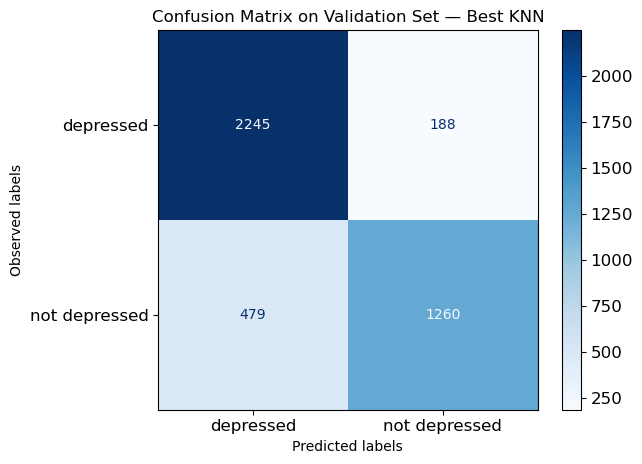

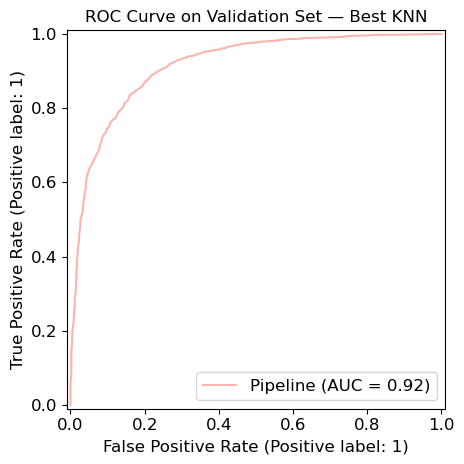

In [ ]:
# Print predicted and actual depression status
final_train_pred_rate = sum(final_train_preds)/len(final_train_preds)
final_val_pred_rate = sum(final_val_preds)/len(final_val_preds)
actual_train_rate = sum(y_train)/len(y_train)
actual_val_rate = sum(y_val)/len(y_val)
print(f"Predicted Depression Rate of Train Set: {final_train_pred_rate:.2%}")
print(f"Predicted Depression Rate of Validation Set: {final_val_pred_rate:.2%}")
print(f"Actual Depression Rate of Train Set: {actual_train_rate:.2%}")
print(f"Actual Depression Rate of Validation Set: {actual_val_rate:.2%}")
print(f"\nFinal Selected Model - {final_model_name}:")

# Confusion matrix
fig, ax = plt.subplots()
ax.grid(False) 
confusion_mat = confusion_matrix(y_val, final_val_preds, labels=[1, 0])
disp_cf = ConfusionMatrixDisplay(confusion_matrix=confusion_mat, display_labels=['depressed', 'not depressed'])
disp_cf.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)

# Adjust font size
for labels in disp_cf.text_.ravel():
    labels.set_fontsize(10) # Set your desired font size here
# Adjust axis label font sizes
ax.set_xlabel('Predicted labels', fontsize=10)
ax.set_ylabel('Observed labels', fontsize=10)

plt.title(f"Confusion Matrix on Validation Set — Best {final_model_name}", fontsize=12)
plt.tight_layout()
plt.show()

# ROC Curve
disp_roc =RocCurveDisplay.from_estimator(final_model, X_val, y_val)

plt.title(f"ROC Curve on Validation Set — Best {final_model_name}", fontsize=12)
plt.tight_layout()
plt.show()

- Using the validation set, the predicted depression rate is 65.29%, which is greater than the actual depression rate of 58.32%.
- The confusion matrix also confirms that the model is less likely to produce a false negative (188) than a false positive (479).
- The AUC score is 0.92, which is high (> 0.9).

### 10.3 Analysis of Misclassifications
Examine data which are misclassified to see if error patterns can be found.

Create a copoy of the Development set, and add `Actual Depresion`, `Predicted Depression`, and `Model Prediction` columns.

In [ ]:
# Examine the rows where final_test_preds and y_test are different to understand the misclassifications by creating a new DataFrame with a new column indicating whether the prediction was correct or not.
misclassified = X_val.copy()
misclassified['Actual Depression'] = y_val
misclassified['Predicted Depression'] = final_val_preds
misclassified['Model Prediction'] = misclassified['Actual Depression'] == misclassified['Predicted Depression']
misclassified['Model Prediction'] = misclassified['Model Prediction'].map({True: 'Correct', False: 'Misclassified'})
misclassified.sample(5)


,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Has Had Suicidal Thoughts,Study Hours,Financial Stress,Family History of Mental Illness,Actual Depression,Predicted Depression,Model Prediction
343,Female,20.0,5.0,7.04,4.0,7.5,Moderate,Yes,12.0,5.0,No,1,1,Correct
3715,Female,33.0,5.0,9.39,1.0,7.5,Unhealthy,Yes,2.0,5.0,Yes,1,1,Correct
6451,Male,32.0,5.0,9.02,2.0,7.5,Unhealthy,Yes,12.0,4.0,Yes,1,1,Correct
260,Male,27.0,1.0,7.47,1.0,3.5,Moderate,Yes,12.0,1.0,No,0,0,Correct
1437,Male,21.0,2.0,8.21,3.0,7.5,Unhealthy,Yes,12.0,5.0,Yes,1,1,Correct


Plot distributions of features by model prediction result to see if the distributions of correctly classified and misclassified data exhibit different patterns.

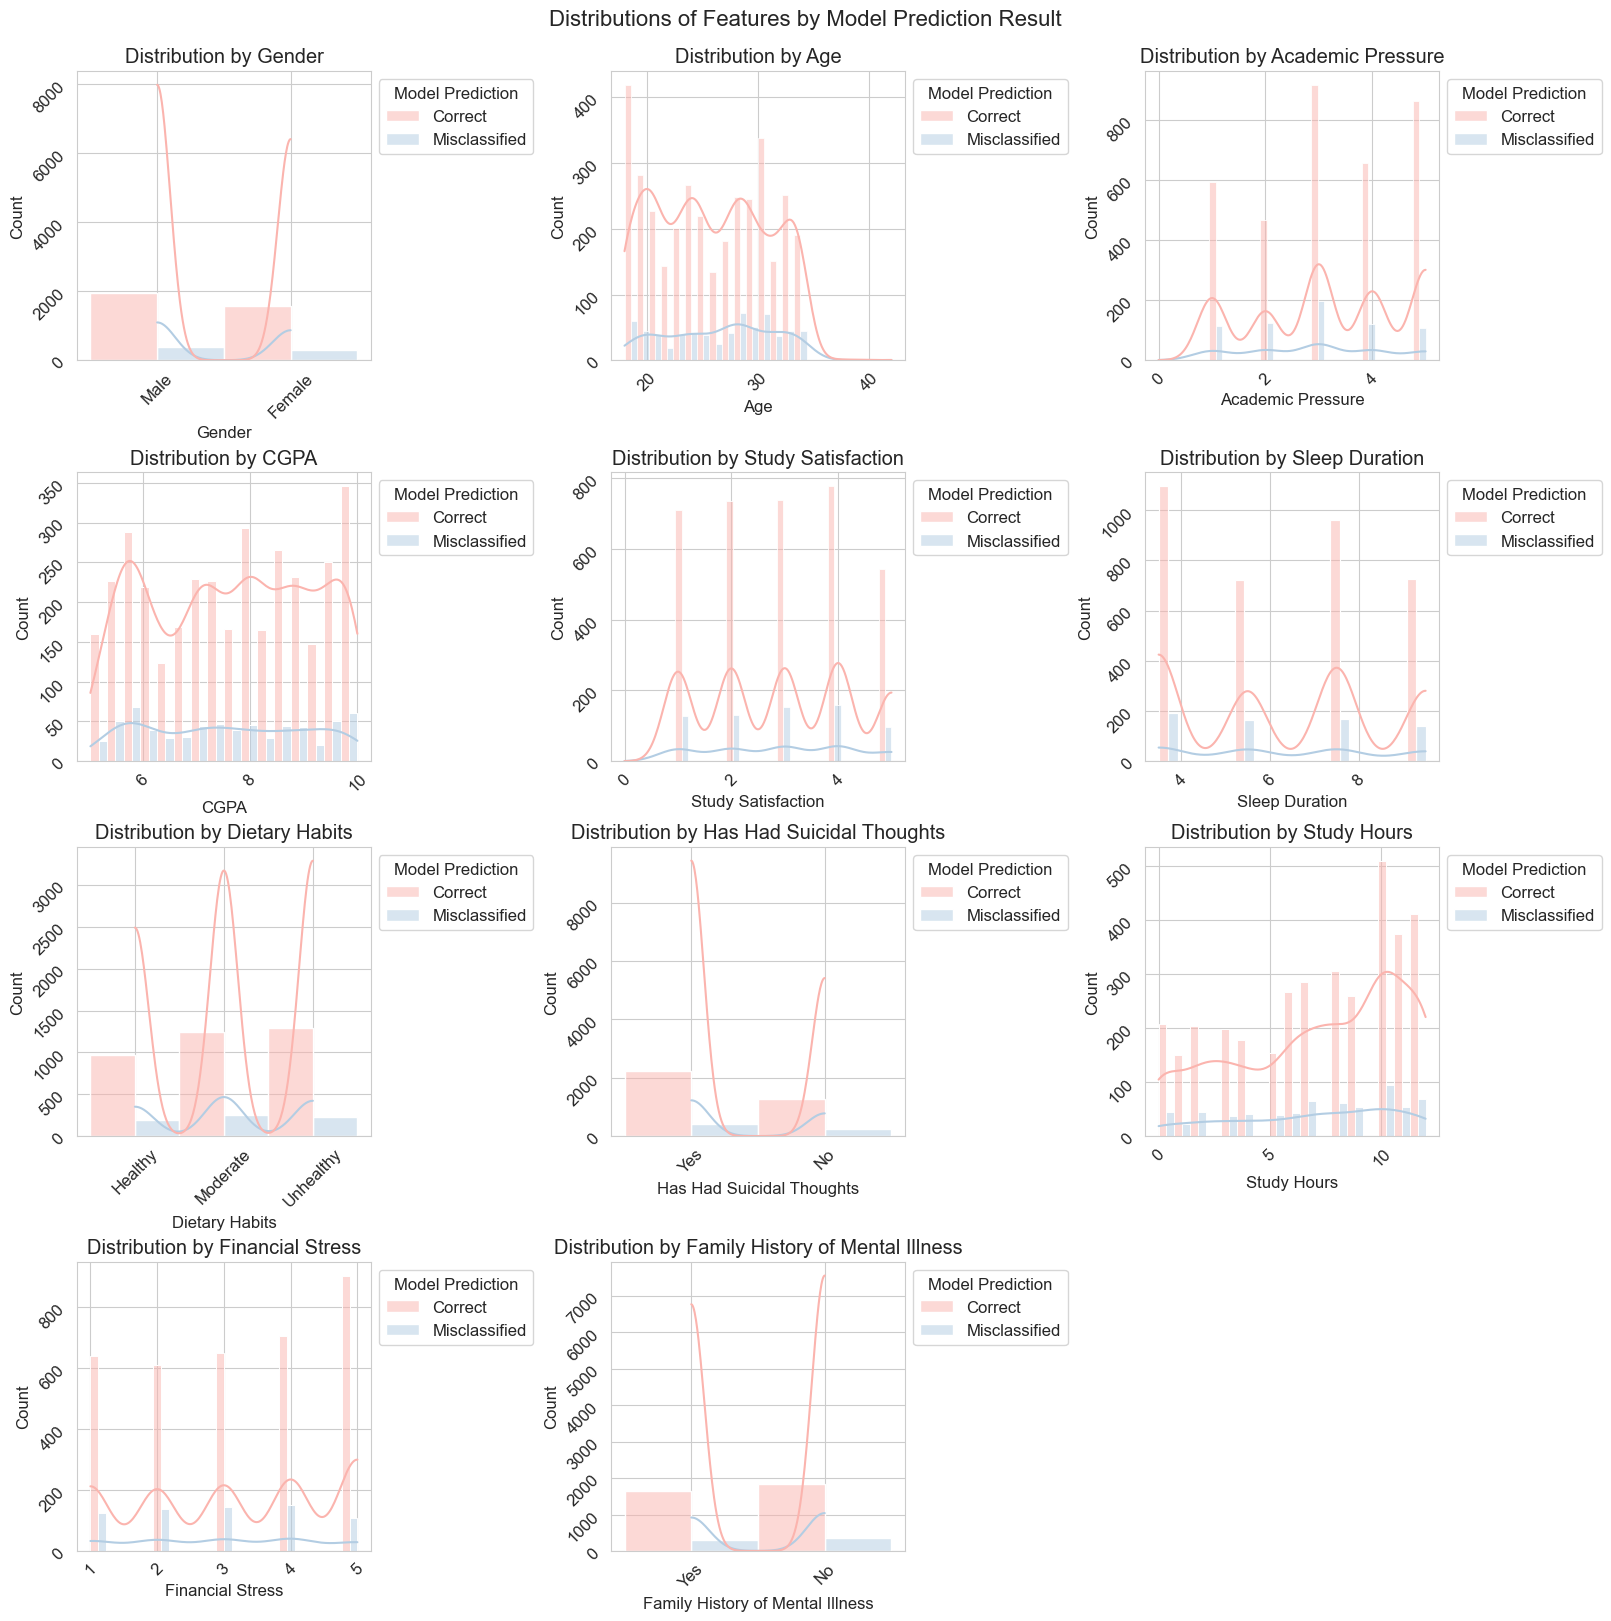

In [ ]:
# Set up subplots
fig,_axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 16), layout='constrained')
axes=_axes.flatten()
# Delete unused subplot and adjust spacing
fig.delaxes(axes[-1]) 
sns.set_style("whitegrid")

# Plot distr
i=0
for col in X_val.columns:
    ax = sns.histplot(data =misclassified, x =col, ax=axes[i], hue='Model Prediction', multiple='dodge', alpha=0.5, kde=True)
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    ax.tick_params(labelrotation=45, labelsize=12)
    ax.set_title(f'Distribution by {col}')
    i=i+1

plt.suptitle('Distributions of Features by Model Prediction Result', fontsize=16, verticalalignment='center')
plt.show()

The plot shows that the distributions of `Study Hours` are different for correctly classified data and incorrectly classified data. 

This may be where the errors come from as shown in the feature distribution plot of misclassified data, where the distributions of study hours for depressed and non-depressed students look different. The inital EDA suggests that those who study less are less likely to be depressed, but those who study more may not be depressed. The value of study hours is only useful when it is low. When number of study hours is high, it is not a good predictor for depression among students.

---
## 11. Model Interpretation and Explainability — Validation Set

### 11.1 Feature Importance by SHAP Values Using KernelExplainer 

In [ ]:
# SHAP values for the final model 
def predict_fn(X):
    X_df = pd.DataFrame(X, columns=X_train.columns)
    return final_model.predict_proba(X_df)[:, 1]

background = shap.sample(X_train, 100, random_state=RANDOM_STATE)
explainer = shap.KernelExplainer(predict_fn, background)

X_val_sample = X_val[:100] 
shap_values_val = explainer.shap_values(X_val_sample, nsamples=100)

  0%|          | 0/100 [00:00<?, ?it/s]

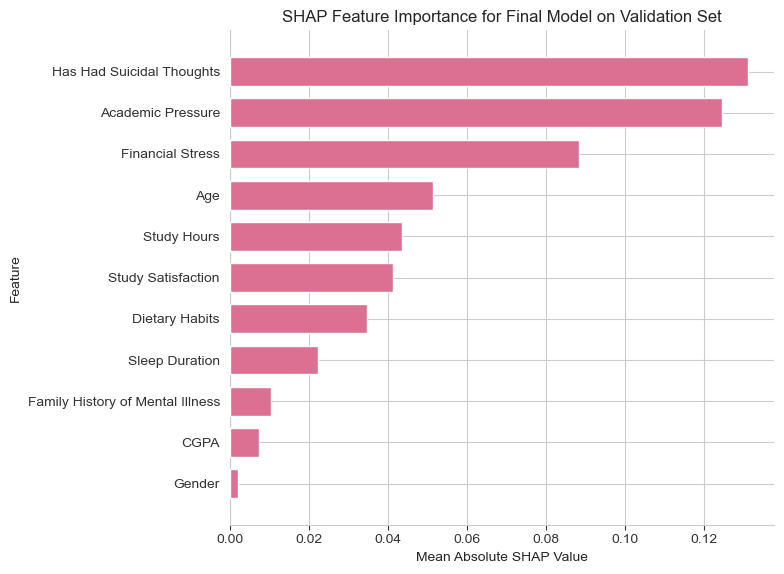

In [ ]:
shap.summary_plot(shap_values_val, X_val_sample, feature_names=X_val.columns, plot_type='bar', show=False, color='palevioletred')
plt.title('SHAP Feature Importance for Final Model on Validation Set', fontsize=12)
plt.xlabel('Mean Absolute SHAP Value', fontsize=10)
plt.ylabel('Feature', fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# Create a DataFrame of SHAP values
shap_table_val = pd.DataFrame({
    'Feature':    X_train.columns.tolist(),
    'Mean |SHAP|': np.abs(shap_values_val).mean(axis=0),
    'Mean SHAP':   shap_values_val.mean(axis=0)        
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)
shap_table_val = shap_table_val[['Feature', 'Mean |SHAP|', 'Mean SHAP']]
print("Global SHAP Feature Importance on Validation Set:")
shap_table_val

Global SHAP Feature Importance on Validation Set:


,Feature,Mean |SHAP|,Mean SHAP
0,Has Had Suicidal Thoughts,0.131040,0.014959
1,Academic Pressure,0.124408,-0.035172
2,Financial Stress,0.088232,0.000103
3,Age,0.051445,0.003140
4,Study Hours,0.043576,0.004722
5,Study Satisfaction,0.041370,0.001182
6,Dietary Habits,0.034840,-0.001468
7,Sleep Duration,0.022217,-0.002147
8,Family History of Mental Illness,0.010378,-0.000158
9,CGPA,0.007382,-0.000043


### 11.2 Top Three Features

The most important 5 features are:
 - Has Had Suicidal Thoughts - This is the strongest indicator and makes perfect sense because those who are not depressed are unlikely to have had suicidal thoughts.
 - Academic Pressure - Those with higher academic pressure are more likely to be depressed.
 - Financial Stress - Those with higher financial stress are more likely to be depressed.

---
## 12. Model Validation and Testing — Held-out Test Set

Here is the final evaluation of the best model using the held-out test set.

### 12.1 Classification Report on Test Set

In [318]:
# Predict on the test set using the final model
final_test_preds = final_model.predict(X_test)
final_recall_test = recall_score(y_test, final_test_preds)
print(f"Recall Score of the Final Model on the Test Set: {final_recall_test:.4f}\n")

# Generate the classification report 
report_dict_test = classification_report(y_test, final_test_preds, target_names= ['Not Depressed', 'Depressed'])
print("Classification Report for the Final Model on the Test Set:")

print (report_dict_test)

Recall Score of the Final Model on the Test Set: 0.9299

Classification Report for the Final Model on the Test Set:
               precision    recall  f1-score   support

Not Depressed       0.89      0.74      0.81      1804
    Depressed       0.82      0.93      0.87      2369

     accuracy                           0.85      4173
    macro avg       0.86      0.83      0.84      4173
 weighted avg       0.85      0.85      0.84      4173



The final recall score on the test set is 0.9299, which has a gap of less than 2% compared to the recall scores of the train set (0.9230), the validation set (0.9227), and the baseline model (0.888).

- Final model:          KNN  — n_neighbors = 78, uniform weights, euclidean metric
- Train recall score:         0.9230
- Validation recall score:    0.9227
- Test recall score:          0.9299

### 12.2 Confusion Matrix and ROC-AUC Curve on Test Set

Predicted Depression Rate of Test Set: 64.15%
Actual Depression Rate of Test Set: 56.77%

Final Selected Model - KNN:


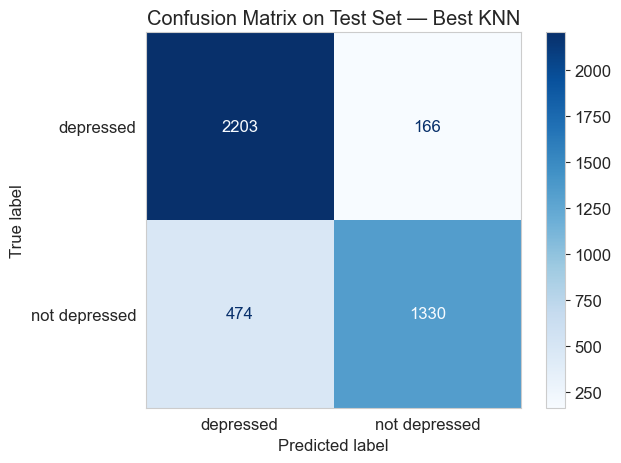

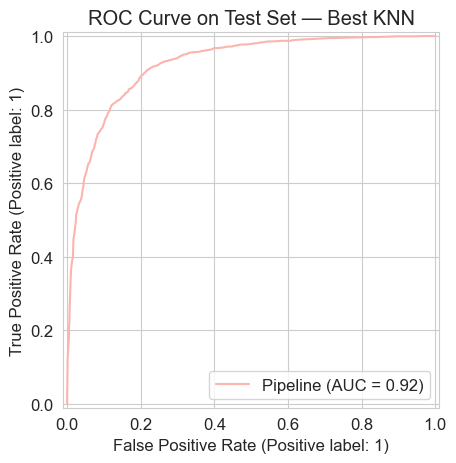

In [ ]:
# Print predicted and actual depression status for the test set
final_test_pred_rate = sum(final_test_preds)/len(final_test_preds)
actual_test_rate = sum(y_test)/len(y_test)
print(f"Predicted Depression Rate of Test Set: {final_test_pred_rate:.2%}")
print(f"Actual Depression Rate of Test Set: {actual_test_rate:.2%}")
print(f"\nFinal Selected Model - {final_model_name}:")

# Confusion matrix
fig, ax = plt.subplots()
ax.grid(False) 
confusion_mat = confusion_matrix(y_test, final_test_preds, labels=[1, 0])
disp_cf = ConfusionMatrixDisplay(confusion_matrix=confusion_mat, display_labels=['depressed', 'not depressed'])
disp_cf.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)
plt.title(f"Confusion Matrix on Test Set — Best {final_model_name}")
plt.tight_layout()
plt.show()

# ROC Curve
disp_roc =RocCurveDisplay.from_estimator(final_model, X_test, y_test)
plt.title(f"ROC Curve on Test Set — Best {final_model_name}")
plt.tight_layout()
plt.show()

Consisten with the results using validation set: 
- The model is less likely to produce a false negative (166) than a false positive (474).
- The AUC score is 0.92, which is high (> 0.9).

### 12.3 Feature Importance by SHAP Values Using KernelExplainer on Test Set

In [ ]:
# SHAP values for the final model on the test set
X_test_sample = X_test[:100] 
shap_values_test = explainer.shap_values(X_test_sample, nsamples=100)

  0%|          | 0/100 [00:00<?, ?it/s]

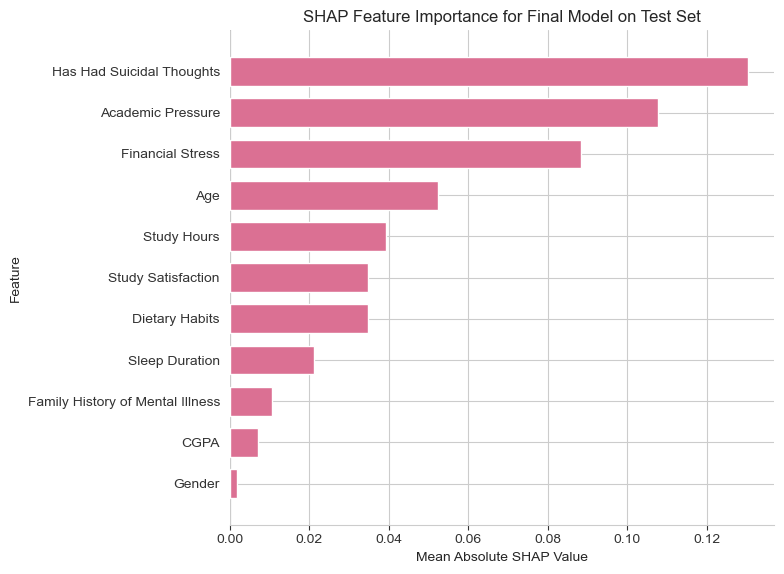

In [ ]:
shap.summary_plot(shap_values_test , X_test_sample, feature_names=X_test.columns, plot_type='bar', show=False, color='palevioletred')
plt.title('SHAP Feature Importance for Final Model on Test Set', fontsize=12)
plt.xlabel('Mean Absolute SHAP Value', fontsize=10)
plt.ylabel('Feature', fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# Create a DataFrame of SHAP values
shap_table_test = pd.DataFrame({
    'Feature':    X_train.columns.tolist(),
    'Mean |SHAP|': np.abs(shap_values_test).mean(axis=0),
    'Mean SHAP':   shap_values_test.mean(axis=0)        
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)
shap_table_test = shap_table_test[['Feature', 'Mean |SHAP|', 'Mean SHAP']]
print("Global SHAP Feature Importance on Test Set:")
shap_table_test

Global SHAP Feature Importance on Test Set:


,Feature,Mean |SHAP|,Mean SHAP
0,Has Had Suicidal Thoughts,0.130423,0.033911
1,Academic Pressure,0.107856,-0.022837
2,Financial Stress,0.088445,0.003300
3,Age,0.052463,0.019176
4,Study Hours,0.039356,0.007530
5,Study Satisfaction,0.034876,-0.003346
6,Dietary Habits,0.034714,0.001888
7,Sleep Duration,0.021339,0.003213
8,Family History of Mental Illness,0.010642,-0.001639
9,CGPA,0.007198,0.000404


Consistent with results from the validation set, the top 3 most important features contributing to student depression in descending order are:
- Has Had Suicidal Thoughts
- Academic Pressure
- Fianacial Stress

### 12.4 Fairness Auditing — Check Performance by Subgroup (Gender, Age)

Check how the model performs by gender.

In [ ]:
depress_test = X_test.copy()
depress_test['Depression'] = y_test

In [ ]:
# Separate the test dataset by gender
X_test_male = X_test[X_test['Gender'] == 'Male']
X_test_female = X_test[X_test['Gender'] == 'Female']
# create the target where gender is male
y_test_male = depress_test[depress_test['Gender'] == 'Male']['Depression']
# create the target where gender is female
y_test_female = depress_test[depress_test['Gender'] == 'Female']['Depression']

In [ ]:
# Predict on the test set using the final model
final_test_preds_male = final_model.predict(X_test_male)
final_test_preds_female = final_model.predict(X_test_female)

# Generate the classification report 
report_dict_test_male = classification_report(y_test_male, final_test_preds_male, target_names= ['Not Depressed', 'Depressed'])
report_dict_test_female = classification_report(y_test_female, final_test_preds_female, target_names= ['Not Depressed', 'Depressed'])
print("Classification Report on Test Set - Male Only:")
print (report_dict_test_male)
print("Classification Report on Test Set - Female Only:")
print (report_dict_test_female)

Classification Report on Test Set - Male Only:
               precision    recall  f1-score   support

Not Depressed       0.89      0.76      0.82      1003
    Depressed       0.83      0.93      0.88      1300

     accuracy                           0.86      2303
    macro avg       0.86      0.84      0.85      2303
 weighted avg       0.86      0.86      0.85      2303

Classification Report on Test Set - Female Only:
               precision    recall  f1-score   support

Not Depressed       0.88      0.71      0.79       801
    Depressed       0.81      0.93      0.87      1069

     accuracy                           0.84      1870
    macro avg       0.85      0.82      0.83      1870
 weighted avg       0.84      0.84      0.83      1870



The model performs eually well on both male (0.93) and female (0.93) test sets, which is consistent with the recall score score predicted using the entire test dataset (0.93).

Now check how the final model performs by age group.
- <= 25 years old
- \> 25 years old


In [ ]:
# Separate the test dataset by age
X_test_less_25 = X_test[X_test['Age'] <= 25]
X_test_more_25 = X_test[X_test['Age'] > 25]
# create the target where age is less than or equal to 25
y_test_less_25 = depress_test[depress_test['Age'] <= 25]['Depression']
# create the target where age is greater than 25
y_test_more_25 = depress_test[depress_test['Age'] > 25]['Depression']

In [ ]:
# Predict on the test set using the final model
final_test_preds_less_25 = final_model.predict(X_test_less_25)
final_test_preds_more_25 = final_model.predict(X_test_more_25)

# Generate the classification report 
report_dict_test_less_25 = classification_report(y_test_less_25, final_test_preds_less_25, target_names= ['Not Depressed', 'Depressed'])
report_dict_test_more_25 = classification_report(y_test_more_25, final_test_preds_more_25, target_names= ['Not Depressed', 'Depressed'])
print("Classification Report on Test Set - Age <= 25:")
print(report_dict_test_less_25)
print("Classification Report on Test Set - Age > 25:")
print(report_dict_test_more_25)

Classification Report on Test Set - Age <= 25:
               precision    recall  f1-score   support

Not Depressed       0.90      0.67      0.77       717
    Depressed       0.84      0.96      0.90      1339

     accuracy                           0.86      2056
    macro avg       0.87      0.81      0.83      2056
 weighted avg       0.86      0.86      0.85      2056

Classification Report on Test Set - Age > 25:
               precision    recall  f1-score   support

Not Depressed       0.89      0.78      0.83      1087
    Depressed       0.79      0.89      0.84      1030

     accuracy                           0.84      2117
    macro avg       0.84      0.84      0.84      2117
 weighted avg       0.84      0.84      0.84      2117



The model peforms really well on students <=25 years old (recall = 0.96), but significanly worse on students > 25 years old (recall = 0.89). This suggests that the current model may not be the best model for predicting depression among students >25 years old, and it needs to be retrained to accurately predict depression among this age group.

---

### 12.5 Robustness Testing — Missing Data

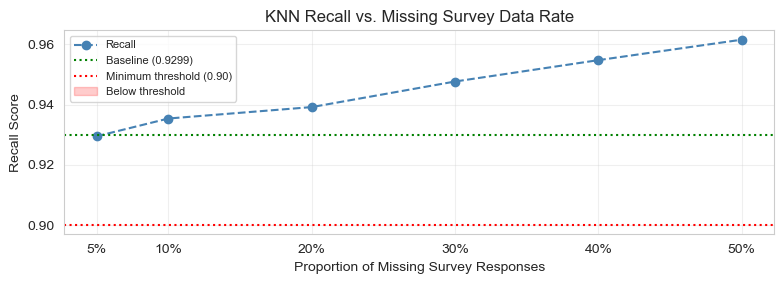

Baseline Recall on Test Set: 0.9299

Recall Drop on Test Set at Various Missing Rates:


,Missing Rate,Recall,Drop,Status
0,5%,0.9295,0.0004,Robust
1,10%,0.9354,-0.0055,Robust
2,20%,0.9392,-0.0093,Robust
3,30%,0.9477,-0.0177,Robust
4,40%,0.9548,-0.0249,Robust
5,50%,0.9616,-0.0317,Robust


In [321]:
# Check model's robustness for missing data under a range of data missing rates
missing_rates=[0.05, 0.10, 0.20, 0.30,0.40, 0.50]

results_robust   = []
baseline_recall  = recall_score(y_test, final_test_preds)

for rate in missing_rates:
    X_missing = X_test.copy()
    missing_indices = np.random.random(X_missing.shape) < rate
    X_missing[missing_indices] = np.nan
    missing_recall = recall_score(y_test, final_model.predict(X_missing))
    drop   = baseline_recall - missing_recall
    results_robust.append({
        'Missing Rate': f"{int(rate*100)}%",
        'Recall': round(missing_recall, 4),
        'Drop': round(drop, 4),
        'Status':   'Fragile' if drop > 0.05
                    else 'Monitor' if drop > 0.02
                    else 'Robust'})

results_missing_df = pd.DataFrame(results_robust)

rates   = [float(r['Missing Rate'].strip('%'))/100 for r in results_robust]
recalls = [r['Recall'] for r in results_robust]

plt.figure(figsize=(8, 3))
plt.plot(rates, recalls, marker='o', linestyle='--', color='steelblue', label='Recall')
plt.axhline(y=baseline_recall, color='green', linestyle=':', label=f'Baseline ({baseline_recall:.4f})')
plt.axhline(y=0.90, color='red',linestyle=':', label='Minimum threshold (0.90)')
plt.fill_between(rates, 0.90, recalls, where=[r < 0.90 for r in recalls], color='red', alpha=0.2,
                     label='Below threshold')

plt.title('KNN Recall vs. Missing Survey Data Rate', fontsize=12)
plt.xlabel('Proportion of Missing Survey Responses', fontsize=10)
plt.ylabel('Recall Score', fontsize=10)
plt.xticks(rates, [f"{int(r*100)}%" for r in rates], fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Baseline Recall on Test Set: {baseline_recall:.4f}\n")
print(f"Recall Drop on Test Set at Various Missing Rates:")
results_missing_df

The model is robust with missing data.

### 12.6 Summary of Results

Final Model: **KNN (n_neighbors = 78, uniform weights, euclidean metric)**
- Baseline recall score: 0.888
- Train recall score:         0.9230
- Validation recall score:    0.9227  — 92.3% of depressed patients correctly identified
- Test recall score:          0.9299 — very close to train and validation recall scores
- Test AUC score: 0.92

Top 5 Features:
- Has Had Suicidal Thoughts
- Academic Pressure
- Fianacial Stress
- Age
- Study Hours

Performance by Subgroup:
- Model performs well across gender groups (male, female).
- Model is biased towards students <= 25 years old (recall = 0.96) compared to students (recall = 0.89). which indicates need for retraining.

Other Limitations:
- KNN is computationally expensive on large datasets
- Model is trained using data collected in India and may fail to predict depression in students in other countries.

---
## 13. Model Monitoring and Maintenance

To monitor this model in production once the model is launched:
- Implement data drift detection
- Data should recollected regularly (e.g. annually) to check if there are changes in feature distributions or target distribution, for example, when depression become more prevelant.
- The performance of the model should be tracked with regularly updated data to ensure its recall score is not compromised.
- Use MLflow and DVC to track experiements and model versions when the model is updated.
- Track recall scores over time with updated data and model to detect model decay.
- The model should be re-trained when recall drops below 0.90.

---

## 14. Iteration and Improvement


### 14.1 Improvemnt on Data Collection

- Proper data collection on student degree, to highlight which majors may be more likley to contribute to student depression.
- Names of city alone are not useful. Consider appending features describing living conditions for the city, such as population density, amount of green spaces, air pollution index, crime rate, infratructure / transport, healthcare access, etc. 
- Include lifetyle features beyond sleep hours and dietary habits, such as exercise hours, socialization / leisure hours, screen time hours.
- Instead of binary values (1/0) for `Depressoin`, consider using a scale to focus on those who are the most depressed.
- The dataset was collected within India. Consider a global survey to expand samples beyond students in India.

### 14.2 Other Models to Explore
- LightGBM, which runs faster than XGBoost and often produces a better recall score, and it also handles tabular data well.
- CatBoost, which is useful if depression data are not numerical but have various catogories.
- GradientBoosting, which is useful to compare against XGBoost.


### 14.3 Fairness Auditing
- Equal opportunity should be used as the metrics to audit model fairness because every demographic group deserves an equal chance of being correctly diagnosed with depression, regardless of gender, age, or ethnicity.


### 14.4 Long-term Maintenance Plan
- Deploy KNN as primary prediction model for best recall
- Use XGBoost as secondary explainability model for clinical review
- Set decision threshold at 0.3–0.4 to further boost recall
- Monitor recall monthly — retrain if recall drops below 0.90
- Run fairness audit** across gender and age groups before deployment
- Implement drift detection to catch data distribution shifts

---

## 15. Conclusion

In this notebook, a supervised machine learning model (KNN) was developed to predict depression among students, using a real-world dataset of 27k samples from students in India. Recall score was chosen as the evaluation metrics, to ensure that at-risk students are identified by minimizing missed depression cases (false negatives). Five classifiers were evaluated — Logistic Regression, KNN, Random Forest, SVM and XGBoost through five rounds of hyperparameter tuning.

Finally. the KNN model was chosen as the best model for achieving the highest validation recall score of 0.9227 with strong generalization to missing data. Using a SHAP KernelExplainer, the top drivers of student depression were identified — whether one has had suicidal thoughts, academic pressure, financial stress.

The notebook demonstrates that machine learning can effectively support depression screening in student populations, achieving a validation recall of 92.2% with strong generalization to unseen data. The results can be used by mental health institutions or practitioners to flag potentially depressed students for early interventions, and the identified top drivers of student depresion are beneficial to universtiy administration and mental health policy makers.

In future work, more data need to be collecetd to include other demographic groups, living conditions, etc. Other models like LightGBM, CatBoost, and GradientBoosting can be explored. Responsible deployment requires continuous performance monitoring, fairness auditing across demographic groups, and regular retraining as student population patterns evolve over time.

This model is intended for research and educational purposes only. It should NOT be used as a standalone clinical diagnostic tool.